# KOTE 증강 실험 재현 메인 노트북

이 노트북 하나를 위에서 아래로 따라가면 `dl-prac-submission` 루트 기준으로 데이터 확인, 증강 산출물 로드/생성, fine-tuning, 리포트 갱신까지 진행할 수 있다.

## 제출 패키징 안내

- 과제 제출 폴더에는 소스코드와 데이터 산출물을 포함한다. 핵심 데이터는 `data/kote/`, `data/augmented/`, `data/aug_seed.csv`, `data/news_db/*.csv`에 있다.
- `backend/data/news.db`에 있던 뉴스 헤드라인/감정 추론 결과는 `scripts/export_news_db_csv.py`로 `data/news_db/headlines.csv`, `data/news_db/emotion_results.csv`, `data/news_db/crawler_meta.csv`로 내보냈다. DB 파일 자체는 로컬 앱 시연용이므로 업로드 제한이 있으면 CSV만 제출해도 된다.
- 모델 가중치와 checkpoint는 용량이 커서 Google Drive 등 대용량 링크로 별도 제출하는 것을 권장한다. 대상은 `resources/kcelectra-base/pytorch_model.bin`, `results/model/*/model.bin`, `results/model/*/ckpt/*.ckpt`이다.
- 최종 앱 실행 모델은 F1-macro 기준 최고 성능인 `results/model/aug_card_scuins_meanir/ckpt/best.ckpt` 또는 같은 run의 `model.bin`이다.
- GitHub 저장소 기준 검증은 `python scripts/validate_artifacts.py --github`로 수행한다. 전체 데이터는 있고 모델만 별도 제출하는 경우는 `--data-only`, 모델 파일까지 포함한 전체 제출본은 옵션 없이 확인한다.

장시간 작업(API 대량 호출, BT 모델 실행, GPU fine-tuning)은 각 `RUN_*` 플래그를 `True`로 바꿀 때만 실행한다. 기본값은 기존 산출물을 로드하는 재현 검사용 흐름이다.


In [1]:
# 0. 인프라 확인: 하드웨어/런타임 정보를 기록한다.
import os
import platform
import subprocess
import sys
from pathlib import Path


def run_optional(cmd):
    try:
        out = subprocess.run(cmd, text=True, capture_output=True, check=False)
        if out.stdout.strip():
            print(out.stdout.strip())
        if out.stderr.strip():
            print(out.stderr.strip())
    except FileNotFoundError:
        print(f"[missing command] {cmd[0]}")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
run_optional(["nvidia-smi"])
print("--- CPU ---")
run_optional(["bash", "-lc", "cat /proc/cpuinfo | grep 'model name' | head -1"])
print("--- Memory ---")
run_optional(["free", "-h"])

try:
    import torch
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA: {torch.version.cuda}")
    print(f"GPU available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU name: {torch.cuda.get_device_name(0)}")
except Exception as exc:
    print(f"torch import failed: {exc}")

Python: 3.10.19
Platform: Linux-6.14.0-1015-nvidia-aarch64-with-glibc2.39
Sun Jun 21 17:58:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GB10                    On  |   0000000F:01:00.0  On |                  N/A |
| N/A   45C    P0             11W /  N/A  | Not Supported          |      0%      Default |
|                                         |                       

PyTorch: 2.10.0+cu130
CUDA: 13.0
GPU available: True
GPU name: NVIDIA GB10


/home/user/projects1/pjh/miniconda3/envs/pjh/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


In [2]:
# 1. 루트 디렉토리 세팅: 이후 모든 경로는 ROOT_DIR 기준으로만 계산한다.
import json
import os
import sys
from pathlib import Path

# 필요하면 이 값을 절대경로로 바꾼다. 기본값은 현재 노트북 위치다.
ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / "main.ipynb").exists() or not (ROOT_DIR / "src" / "kote_trainer.py").exists():
    # Jupyter 실행 위치가 달라도 부모를 거슬러 올라가며 실험 루트를 찾는다.
    for cand in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (cand / "main.ipynb").exists() and (cand / "src" / "kote_trainer.py").exists():
            ROOT_DIR = cand
            break

DATA_DIR = ROOT_DIR / "data"
KOTE_DIR = DATA_DIR / "kote"
AUG_DIR = DATA_DIR / "augmented"
SCRIPTS_DIR = ROOT_DIR / "scripts"
RESULTS_DIR = ROOT_DIR / "results"
MODEL_DIR = RESULTS_DIR / "model"
REPORT_DIR = RESULTS_DIR / "report"
FIGURE_DIR = RESULTS_DIR / "figure"

for path in [DATA_DIR, KOTE_DIR, AUG_DIR, SCRIPTS_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# .env 로드: GEMINI_API_KEY, MODEL_PATH 등을 필요할 때 사용한다.
def load_dotenv_once(path: Path):
    if not path.exists():
        return False
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
    return True

ENV_LOADED = load_dotenv_once(ROOT_DIR / ".env")

from src.kote_trainer import LABELS, NUM_LABELS

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"KOTE_DIR: {KOTE_DIR}")
print(f"AUG_DIR: {AUG_DIR}")
print(f"LABELS: {NUM_LABELS}")
print(f".env loaded: {ENV_LOADED}")

/home/user/projects1/pjh/miniconda3/envs/pjh/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT_DIR: /home/user/projects1/pjh/lab-w18/dl-prac-submission
KOTE_DIR: /home/user/projects1/pjh/lab-w18/dl-prac-submission/data/kote
AUG_DIR: /home/user/projects1/pjh/lab-w18/dl-prac-submission/data/augmented
LABELS: 44
.env loaded: False


## 실행 플래그

기본값은 모두 `False`다. 기존 파일이 있으면 로드하고, 새로 재현할 때만 해당 플래그를 `True`로 바꾼다.

최종 비교는 원논문 설정에 맞춰 baseline / Back Translation / card & SCUins를 epoch 10 결과로 맞춘다. 이 실험의 기본 모델 run명은 이미 epoch 10 결과를 담고 있다.


In [3]:
RUN_VALIDATE_ARTIFACTS = True   # True: validate_artifacts.py 실행 / False: 건너뜀
RUN_REBUILD_REPORTS = True      # True: build_reports.py 실행 / False: 건너뜀

RUN_BASELINE_FINETUNE = False      # True: GPU 파인튜닝 실행 / False: results/model/baseline_th03/metrics.json 로드
RUN_AUG_GEMINI_GENERATION = False  # True: Gemini API로 paraphrase 증강 생성 (GEMINI_API_KEY 필요) / False: data/augmented/total_seed_gemini_aug/ 기존 파일 사용
RUN_AUG_GEMINI_FINETUNE = False    # True: Gemini 증강 파인튜닝 실행 / False: results/model/total_seed_gemini_aug_meanir/metrics.json 로드
RUN_BT_GENERATION = False          # True: BT generation 실행 / False: data/augmented/bt/aug_bt_need19947_s42.jsonl 기존 파일 사용
RUN_BT_REPAIR = False              # True: BT repair 실행 / False: data/augmented/bt/aug_bt_need19947_s42_repaired.jsonl 기존 파일 사용
RUN_BT_FINETUNE = False            # True: BT 증강 파인튜닝 실행 / False: results/model/aug_bt_need19947_s42_repaired/metrics.json 로드
RUN_CARD_SCUINS_GENERATION = False # True: card/SCUins seed로 Gemini 증강 생성 (GEMINI_API_KEY 필요) / False: data/augmented/card_scuins/aug_card_scuins_meanir_raw.jsonl 기존 파일 사용
RUN_CARD_SCUINS_FILTER = False     # True: 품질 필터 실행 / False: data/augmented/card_scuins/aug_card_scuins_meanir.jsonl 기존 파일 사용
RUN_CARD_SCUINS_FINETUNE = False   # True: card/SCUins 증강 파인튜닝 실행 / False: results/model/aug_card_scuins_meanir/metrics.json 로드

EPOCHS = 10
BATCH_SIZE = 16
THRESHOLD = 0.3
SEED = 42


In [4]:
# 2. 실험 산출물 기본 검증
import subprocess

if RUN_VALIDATE_ARTIFACTS:
    subprocess.run(
        [sys.executable, str(SCRIPTS_DIR / "validate_artifacts.py"), "--root", str(ROOT_DIR)],
        cwd=str(ROOT_DIR),
        check=True,
    )
else:
    print("[SKIP] artifact validation")

{
  "root": "/home/user/projects1/pjh/lab-w18/dl-prac-submission",
  "missing": [],
  "counts": {
    "kote_train": 40000,
    "kote_val": 5000,
    "kote_test": 5000,
    "aug_seed_csv_rows_including_header": 19948,
    "total_seed_gemini_aug": 19947,
    "bt_repaired": 19947,
    "card_scuins": 19734,
    "training_history_rows_including_header": 20
  },
  "metrics_runs": [
    "aug_bt_need19947_s42_repaired",
    "aug_card_scuins_meanir",
    "baseline_th03"
  ],
  "metric_problems": []
}


In [5]:
# 3. KOTE split 및 증강 파일 수 확인
from collections import Counter
import csv

paths = {
    "train": KOTE_DIR / "train.tsv",
    "val": KOTE_DIR / "val.tsv",
    "test": KOTE_DIR / "test.tsv",
    "aug_seed": DATA_DIR / "aug_seed.csv",
    "total_seed_gemini_aug": AUG_DIR / "total_seed_gemini_aug" / "total_seed_gemini_aug_meanir.jsonl",
    "bt_repaired": AUG_DIR / "bt" / "aug_bt_need19947_s42_repaired.jsonl",
    "card_scuins": AUG_DIR / "card_scuins" / "aug_card_scuins_meanir.jsonl",
}
for name, path in paths.items():
    if path.exists():
        n = sum(1 for _ in path.open(encoding="utf-8"))
        print(f"{name:<14} {n:>7,}  {path.relative_to(ROOT_DIR)}")
    else:
        print(f"{name:<14} MISSING  {path.relative_to(ROOT_DIR)}")

lengths = []
with (KOTE_DIR / "train.tsv").open(encoding="utf-8") as f:
    for row in csv.reader(f, delimiter="	"):
        if len(row) >= 3:
            lengths.append(len([x for x in row[2].split(",") if x.strip()]))
print(f"train 평균 label cardinality: {sum(lengths) / len(lengths):.2f}")
print(f"train 멀티라벨 비율: {sum(n > 1 for n in lengths) / len(lengths) * 100:.1f}%")

train           40,000  data/kote/train.tsv
val              5,000  data/kote/val.tsv
test             5,000  data/kote/test.tsv
aug_seed        19,948  data/aug_seed.csv
total_seed_gemini_aug  19,947  data/augmented/total_seed_gemini_aug/total_seed_gemini_aug_meanir.jsonl


bt_repaired     19,947  data/augmented/bt/aug_bt_need19947_s42_repaired.jsonl
card_scuins     19,734  data/augmented/card_scuins/aug_card_scuins_meanir.jsonl
train 평균 label cardinality: 7.91
train 멀티라벨 비율: 99.1%


## 데이터/증강 진단 흐름 복원

데이터 분석과 증강 진단 흐름을 이 노트북에서 재구성한 구간이다. 장시간 작업을 수행하지 않고, 이미 보존된 TSV/JSONL/CSV/PNG를 읽어서 실험 설계의 근거를 순서대로 확인한다.

In [6]:
# 분석/시각화 공통 유틸리티
import math
import csv
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import Image, Markdown, display

for _fp in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf", "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"]:
    if Path(_fp).exists():
        fm.fontManager.addfont(_fp)
        plt.rcParams["font.family"] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False


def read_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def count_jsonl(path: Path):
    if not path.exists():
        return None
    with path.open(encoding="utf-8") as f:
        return sum(1 for _ in f)


def show_png(path: Path, title=None):
    if title:
        display(Markdown(f"**{title}**"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[missing] {path.relative_to(ROOT_DIR)}")

### 1. KOTE label count와 IRLbl

Baseline 노트북의 데이터 분석 흐름을 이어서, train split의 라벨 count와 IRLbl을 먼저 확인한다. 이 표와 그림이 이후 MeanIR need, minority 라벨, seed 수량의 기준이 된다.

,label,count,irlbl,is_minority
0,안타까움/실망,17465,1.000000,False
1,불평/불만,16696,1.046059,False
2,어이없음,15996,1.091835,False
3,짜증,14930,1.169792,False
4,화남/분노,12299,1.420034,False
5,한심함,12201,1.431440,False
6,의심/불신,11565,1.510160,False
7,기대감,11197,1.559793,False
8,즐거움/신남,10867,1.607159,False
9,감동/감탄,10778,1.620431,False


train_count: 40,000
MeanIR: 4.055128
minority_label_count: 14
max_freq_label: 안타까움/실망 (17,465)
most imbalanced: 죄책감 IRLbl=25.02149


**기존 label_distribution.png**

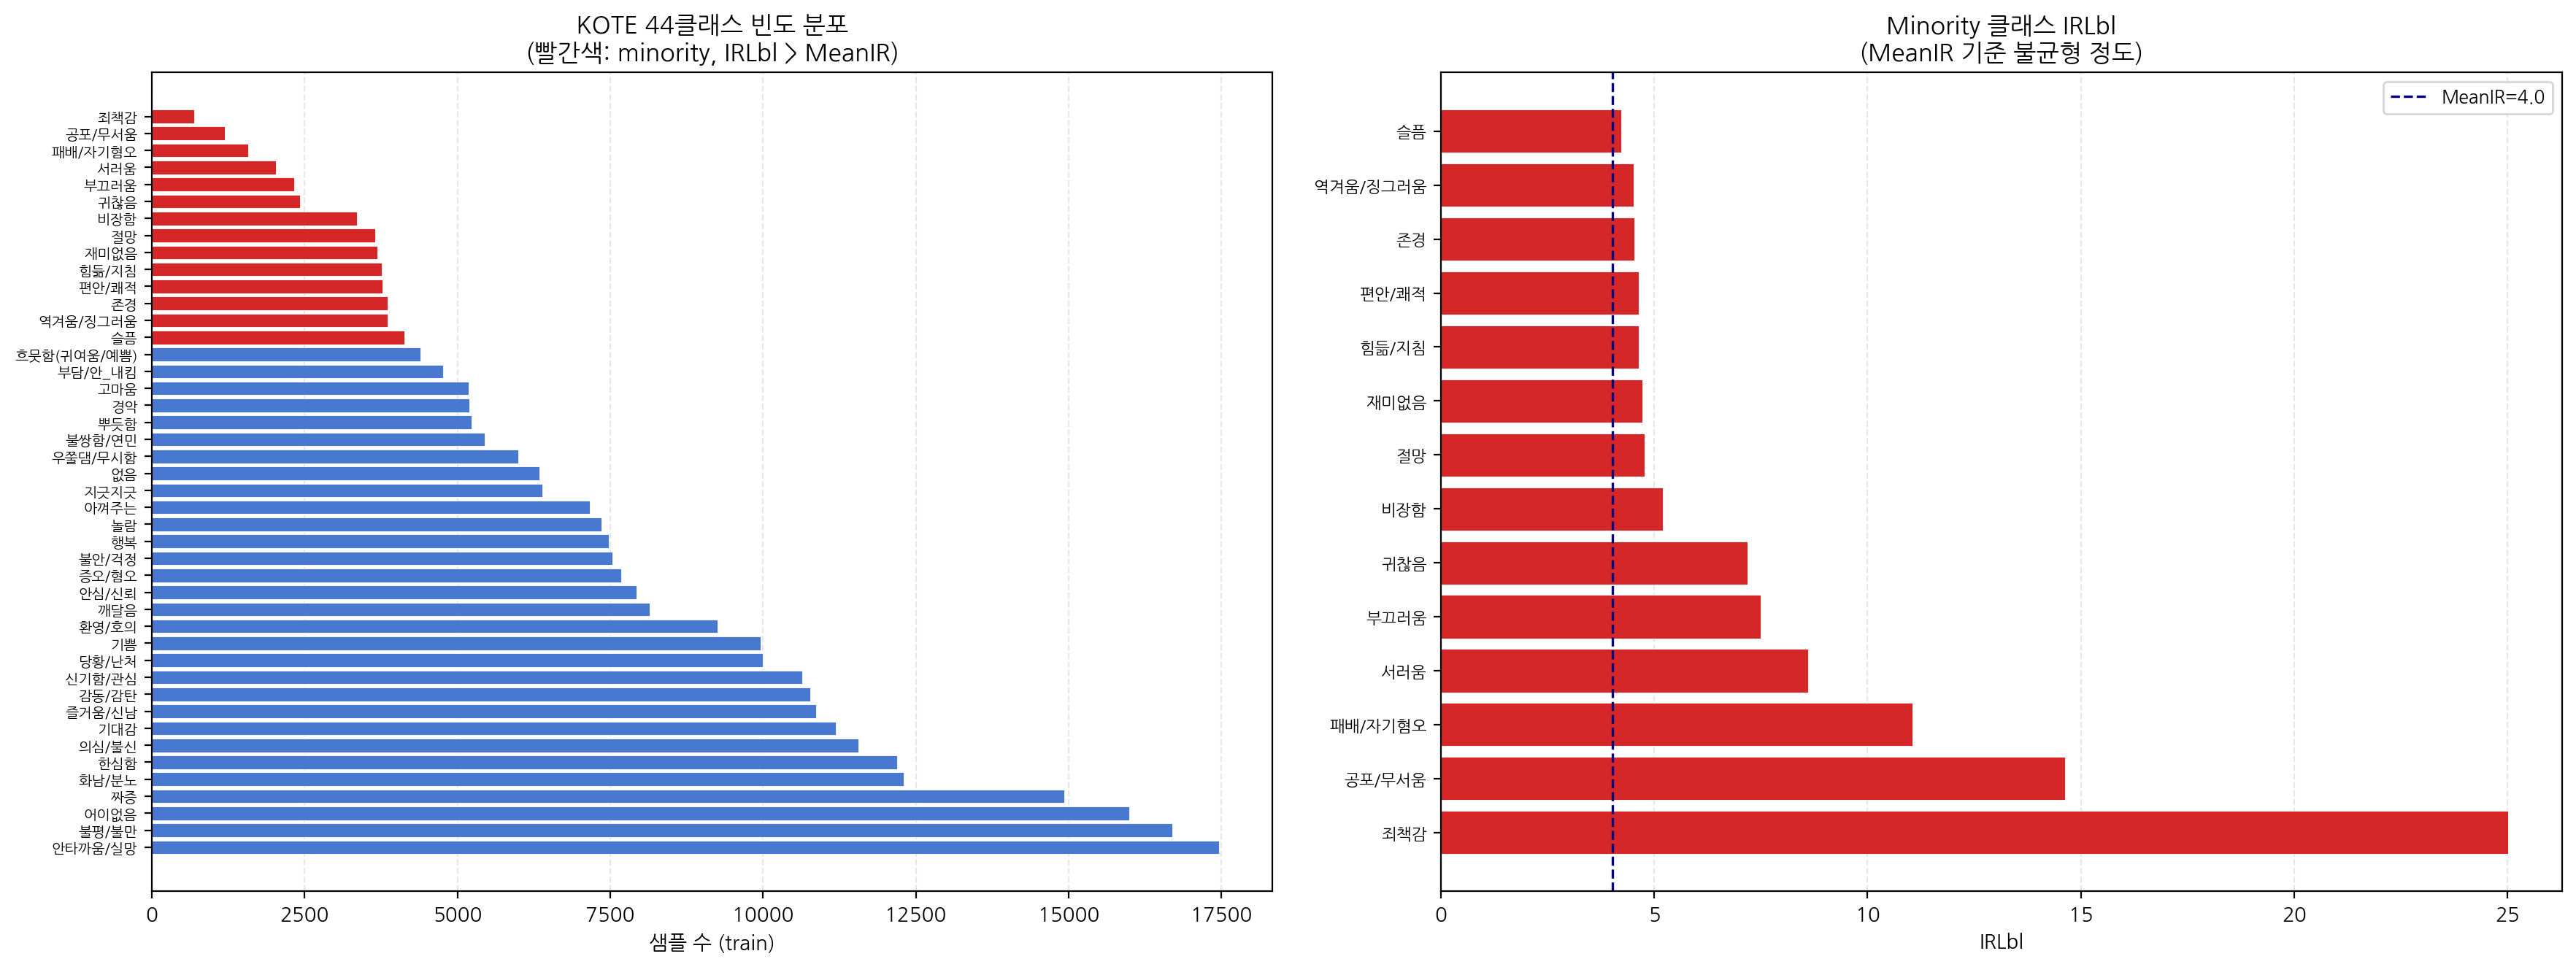

In [7]:
# KOTE train label distribution + IRLbl table
irlbl_summary = json.loads((KOTE_DIR / "irlbl.json").read_text(encoding="utf-8"))
label_count = irlbl_summary["label_count"]
irlbl_map = irlbl_summary["irlbl"]
mean_ir = float(irlbl_summary["mean_ir"])
minority_labels_from_irlbl = set(irlbl_summary["minor_labels"])

label_df = pd.DataFrame({
    "label": LABELS,
    "count": [label_count.get(label, 0) for label in LABELS],
    "irlbl": [irlbl_map.get(label, np.nan) for label in LABELS],
})
label_df["is_minority"] = label_df["label"].isin(minority_labels_from_irlbl)
label_df = label_df.sort_values("count", ascending=False).reset_index(drop=True)

display(label_df)
print(f"train_count: {irlbl_summary['train_count']:,}")
print(f"MeanIR: {mean_ir:.6f}")
print(f"minority_label_count: {len(minority_labels_from_irlbl)}")
print(f"max_freq_label: {irlbl_summary['max_freq_label']} ({irlbl_summary['n_max']:,})")
print(f"most imbalanced: {max(irlbl_map, key=irlbl_map.get)} IRLbl={irlbl_map[max(irlbl_map, key=irlbl_map.get)]:.5f}")

fig_path = FIGURE_DIR / "label_distribution.png"
if fig_path.exists():
    show_png(fig_path, "기존 label_distribution.png")
else:
    fig, ax = plt.subplots(figsize=(12, 8))
    plot_df = label_df.sort_values("count")
    colors = ["#d62728" if x else "#4c78a8" for x in plot_df["is_minority"]]
    ax.barh(plot_df["label"], plot_df["count"], color=colors)
    ax.set_xlabel("train label count")
    ax.set_title("KOTE train label distribution")
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()

### 2. total_seed_gemini_aug 생성 구조 확인

`total_seed_gemini_aug`는 minority 타겟 라벨당 MeanIR need만큼 paraphrase를 생성한 데이터다.
각 행의 `minority_label_target`이 의도한 타겟 라벨이고, `labels`는 원문의 전체 멀티라벨 조합을 그대로 유지한다.

**확인 포인트:**
- **① target 기준 생성량**: `minority_label_target` 집계는 need와 자명하게 일치한다. 생성 스크립트가 라벨당 need를 정확히 채웠기 때문이며, 증강 효과를 검증하는 수치가 아니다.
- **② 실제 labels 분포**: `labels` 필드 전체를 집계하면 원문 조합이 유지되면서 majority 라벨이 함께 증폭된 실제 효과를 볼 수 있다. exp_03_summary의 "majority 오염" 분석 근거가 이 분포다.

,metric,value
0,rows,19947.000
1,mean_label_cardinality,9.899
2,multilabel_ratio_pct,99.750
3,with_majority_label_pct,99.700


**① 생성 target 기준 (minority_label_target 집계 — need와 자명하게 일치)**

,target_label,generated_count
0,죄책감,3609
1,공포/무서움,3113
2,패배/자기혐오,2726
3,서러움,2276
4,부끄러움,1978
5,귀찮음,1879
6,비장함,955
7,절망,655
8,재미없음,616
9,힘듦/지침,538


**② 실제 labels 분포 (labels 필드 전체 집계 — majority 동반 증강 효과)**

,label,actual_count
0,안타까움/실망,12184
1,불평/불만,8974
2,어이없음,8666
3,짜증,8581
4,불안/걱정,8175
5,당황/난처,7900
6,한심함,7500
7,화남/분노,7106
8,슬픔,6461
9,의심/불신,6435


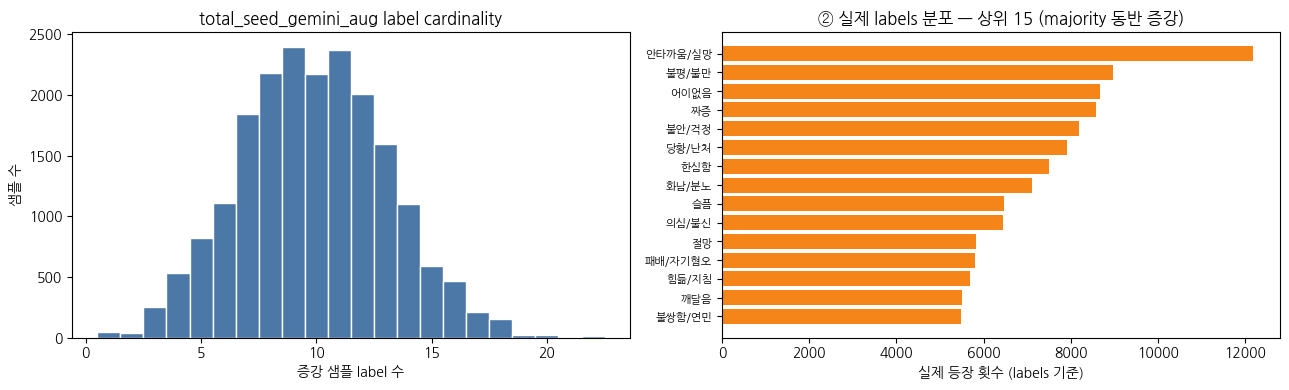

In [8]:
# total_seed_gemini_aug 생성 구조: target 기준 생성량 vs 실제 labels 분포
total_seed_aug_dir = AUG_DIR / "total_seed_gemini_aug"
total_seed_aug_jsonl = total_seed_aug_dir / "total_seed_gemini_aug_meanir.jsonl"
total_seed_label_stats_path = total_seed_aug_dir / "label_stats.json"

total_seed_rows = read_jsonl(total_seed_aug_jsonl)
if total_seed_label_stats_path.exists():
    total_seed_label_stats = json.loads(total_seed_label_stats_path.read_text(encoding="utf-8"))
    total_seed_minority_labels = set(total_seed_label_stats.get("minority_labels", []))
else:
    total_seed_label_stats = {}
    total_seed_minority_labels = minority_labels_from_irlbl

if total_seed_rows:
    label_cardinality = [len(r.get("labels", [])) for r in total_seed_rows]
    has_majority = [any(l not in total_seed_minority_labels and l != "없음" for l in r.get("labels", [])) for r in total_seed_rows]
    has_multi = [len(r.get("labels", [])) > 1 for r in total_seed_rows]

    summary_df = pd.DataFrame([
        {"metric": "rows", "value": len(total_seed_rows)},
        {"metric": "mean_label_cardinality", "value": round(float(np.mean(label_cardinality)), 4)},
        {"metric": "multilabel_ratio_pct", "value": round(float(np.mean(has_multi) * 100), 2)},
        {"metric": "with_majority_label_pct", "value": round(float(np.mean(has_majority) * 100), 2)},
    ])
    display(summary_df)

    # ① target 기준 생성량: minority_label_target 집계 — need와 자명하게 일치 (생성 스크립트 설계상)
    target_counts = Counter(t for r in total_seed_rows for t in r.get("minority_label_target", []))
    display(Markdown("**① 생성 target 기준 (minority_label_target 집계 — need와 자명하게 일치)**"))
    display(pd.DataFrame(target_counts.most_common(), columns=["target_label", "generated_count"]))

    # ② 실제 labels 분포: 원문 조합 유지로 인해 majority 라벨이 동반 증폭된 실제 효과
    actual_label_counts = Counter(l for r in total_seed_rows for l in r.get("labels", []))
    display(Markdown("**② 실제 labels 분포 (labels 필드 전체 집계 — majority 동반 증강 효과)**"))
    display(pd.DataFrame(actual_label_counts.most_common(20), columns=["label", "actual_count"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(label_cardinality, bins=np.arange(1, max(label_cardinality) + 2) - 0.5, color="#4c78a8", edgecolor="white")
    axes[0].set_xlabel("증강 샘플 label 수")
    axes[0].set_ylabel("샘플 수")
    axes[0].set_title("total_seed_gemini_aug label cardinality")

    actual_top = pd.DataFrame(actual_label_counts.most_common(15), columns=["label", "count"])
    axes[1].barh(actual_top["label"][::-1], actual_top["count"][::-1], color="#f58518")
    axes[1].set_xlabel("실제 등장 횟수 (labels 기준)")
    axes[1].set_title("② 실제 labels 분포 — 상위 15 (majority 동반 증강)")
    axes[1].tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    out = FIGURE_DIR / "total_seed_gemini_aug_data_diagnostics.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
else:
    print(f"[missing or empty] {total_seed_aug_jsonl}")

### 3. SCUins/card 통계와 기존 figure 확인

`SCUins <= 0.1` 단일 기준이 모든 minority 라벨에 똑같이 작동하지 않는다는 점이 seed 전략 변경의 핵심 근거다. 저장된 `scumble_scores.jsonl`, `scuins_summary.json` 성격의 통계와 기존 figure를 함께 확인한다.

,metric,value
0,n_samples,40000.000000
1,SCUins mean,0.107964
2,SCUins median,0.084119
3,SCUins p75,0.148224
4,SCUins max,0.628702
5,card mean,7.752900
6,card p30,6.000000
7,has minority rows,23570.000000
8,SCUins <= 0.1 rows,22865.000000


,label,irlbl,count,strict_n_scuins_le_0_1,strict_ratio_pct,p25,p50,p75
0,죄책감,25.021490,698,0,0.00,0.366592,0.403369,0.442772
1,공포/무서움,14.627303,1194,8,0.67,0.268036,0.299717,0.335927
2,패배/자기혐오,11.046806,1581,5,0.32,0.226938,0.259767,0.308527
3,서러움,8.599212,2031,29,1.43,0.187352,0.221490,0.263715
4,부끄러움,7.498927,2329,8,0.34,0.178584,0.204831,0.244718
5,귀찮음,7.193163,2428,55,2.27,0.161825,0.194607,0.226056
6,비장함,5.210322,3352,751,22.40,0.103489,0.138022,0.177301
7,절망,4.782311,3652,151,4.13,0.139699,0.173209,0.229433
8,재미없음,4.731780,3691,224,6.07,0.134675,0.159785,0.193860
9,힘듦/지침,4.633855,3769,632,16.77,0.116869,0.159501,0.213791


**SCUins 전체 분포**

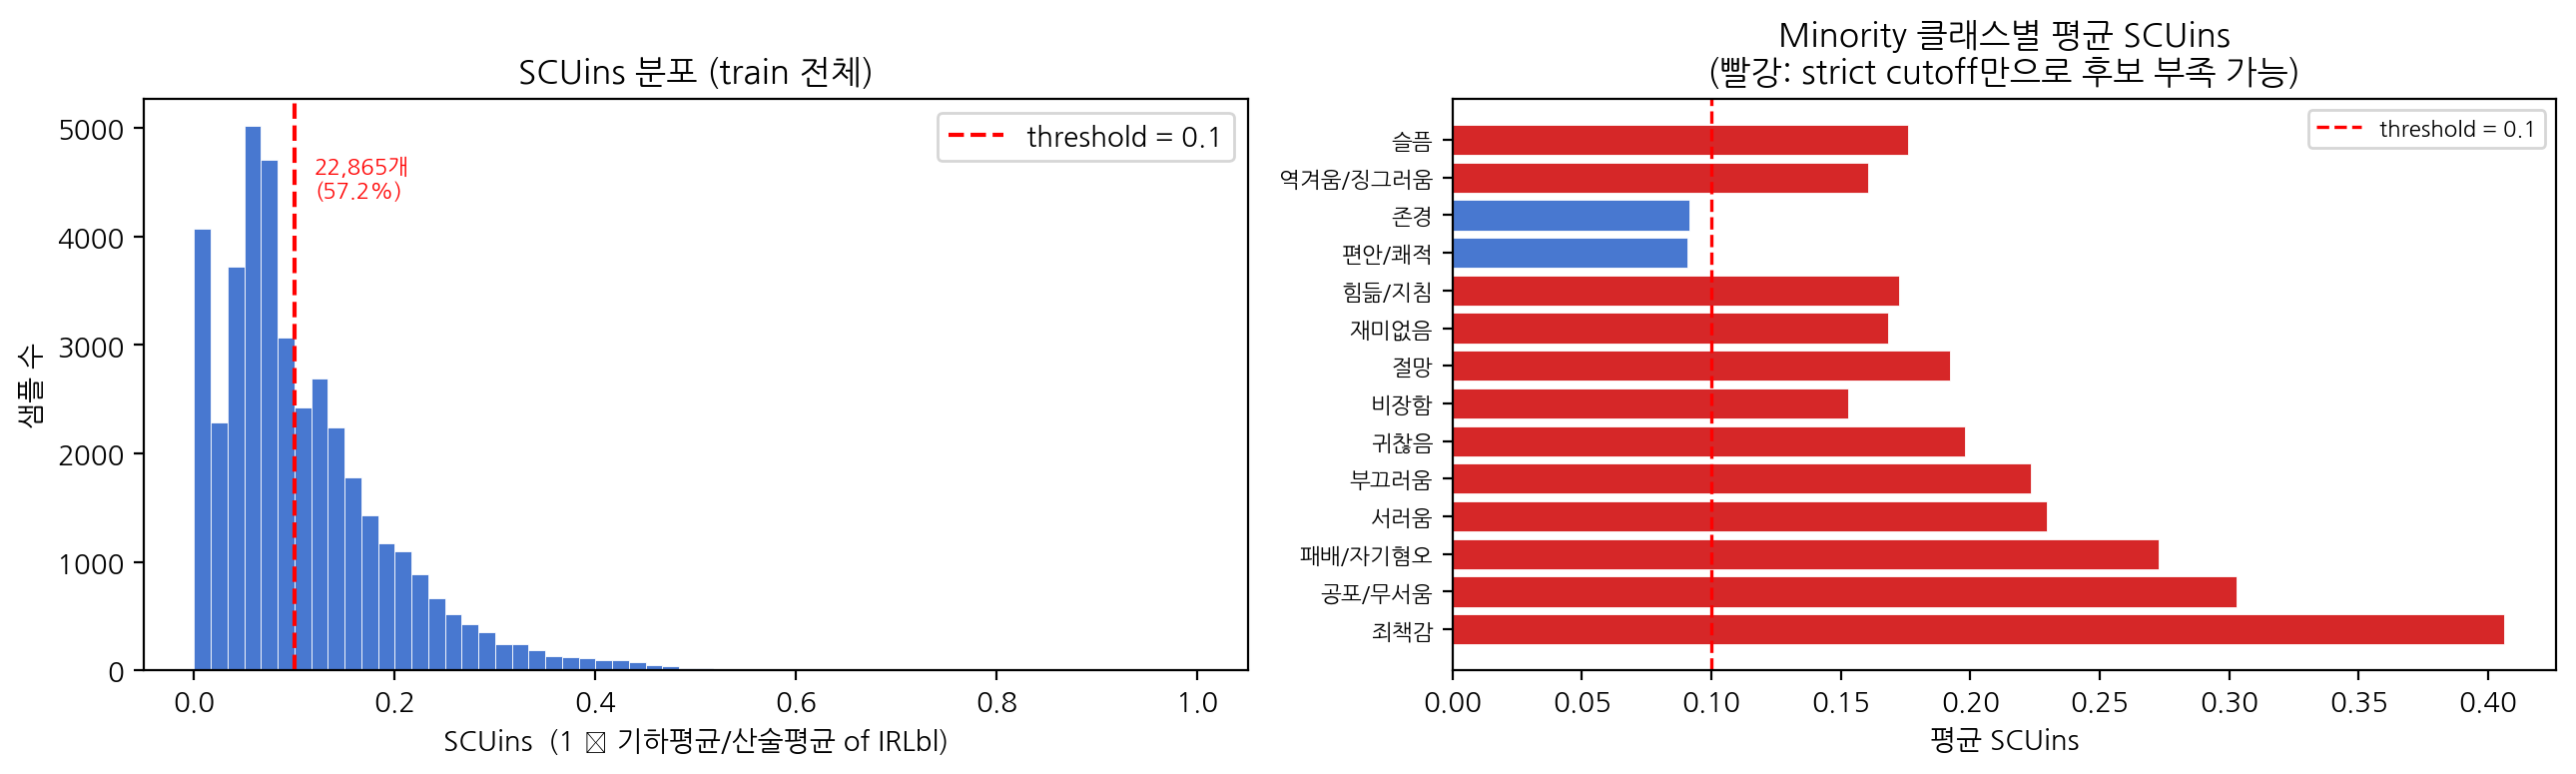

**minority SCUins boxplot**

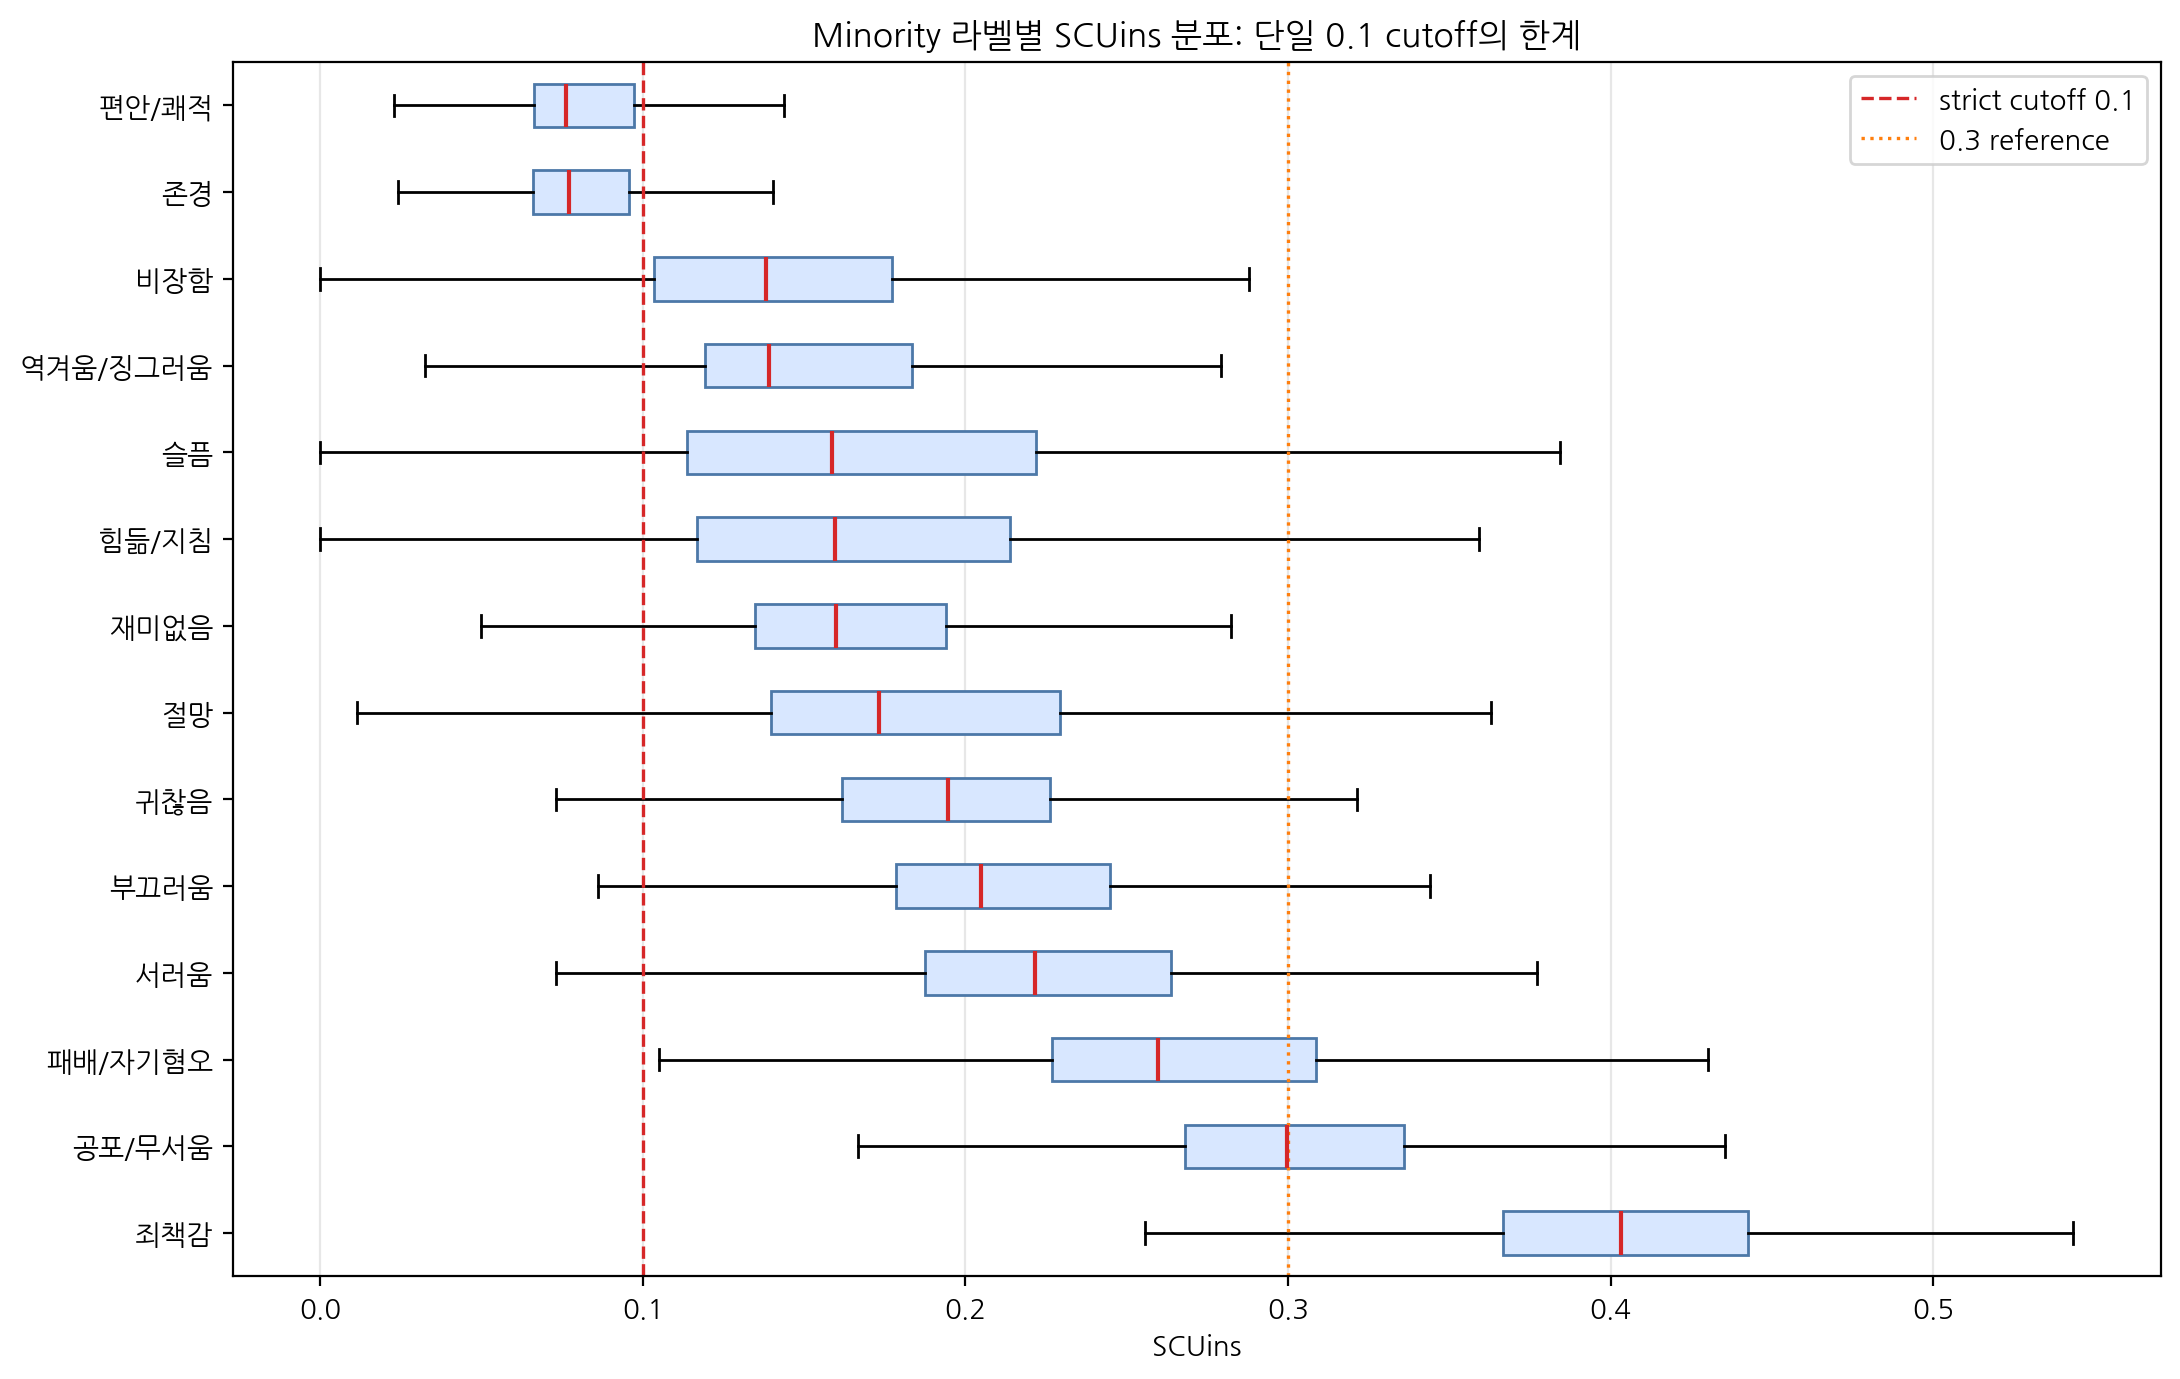

**strict 후보 수**

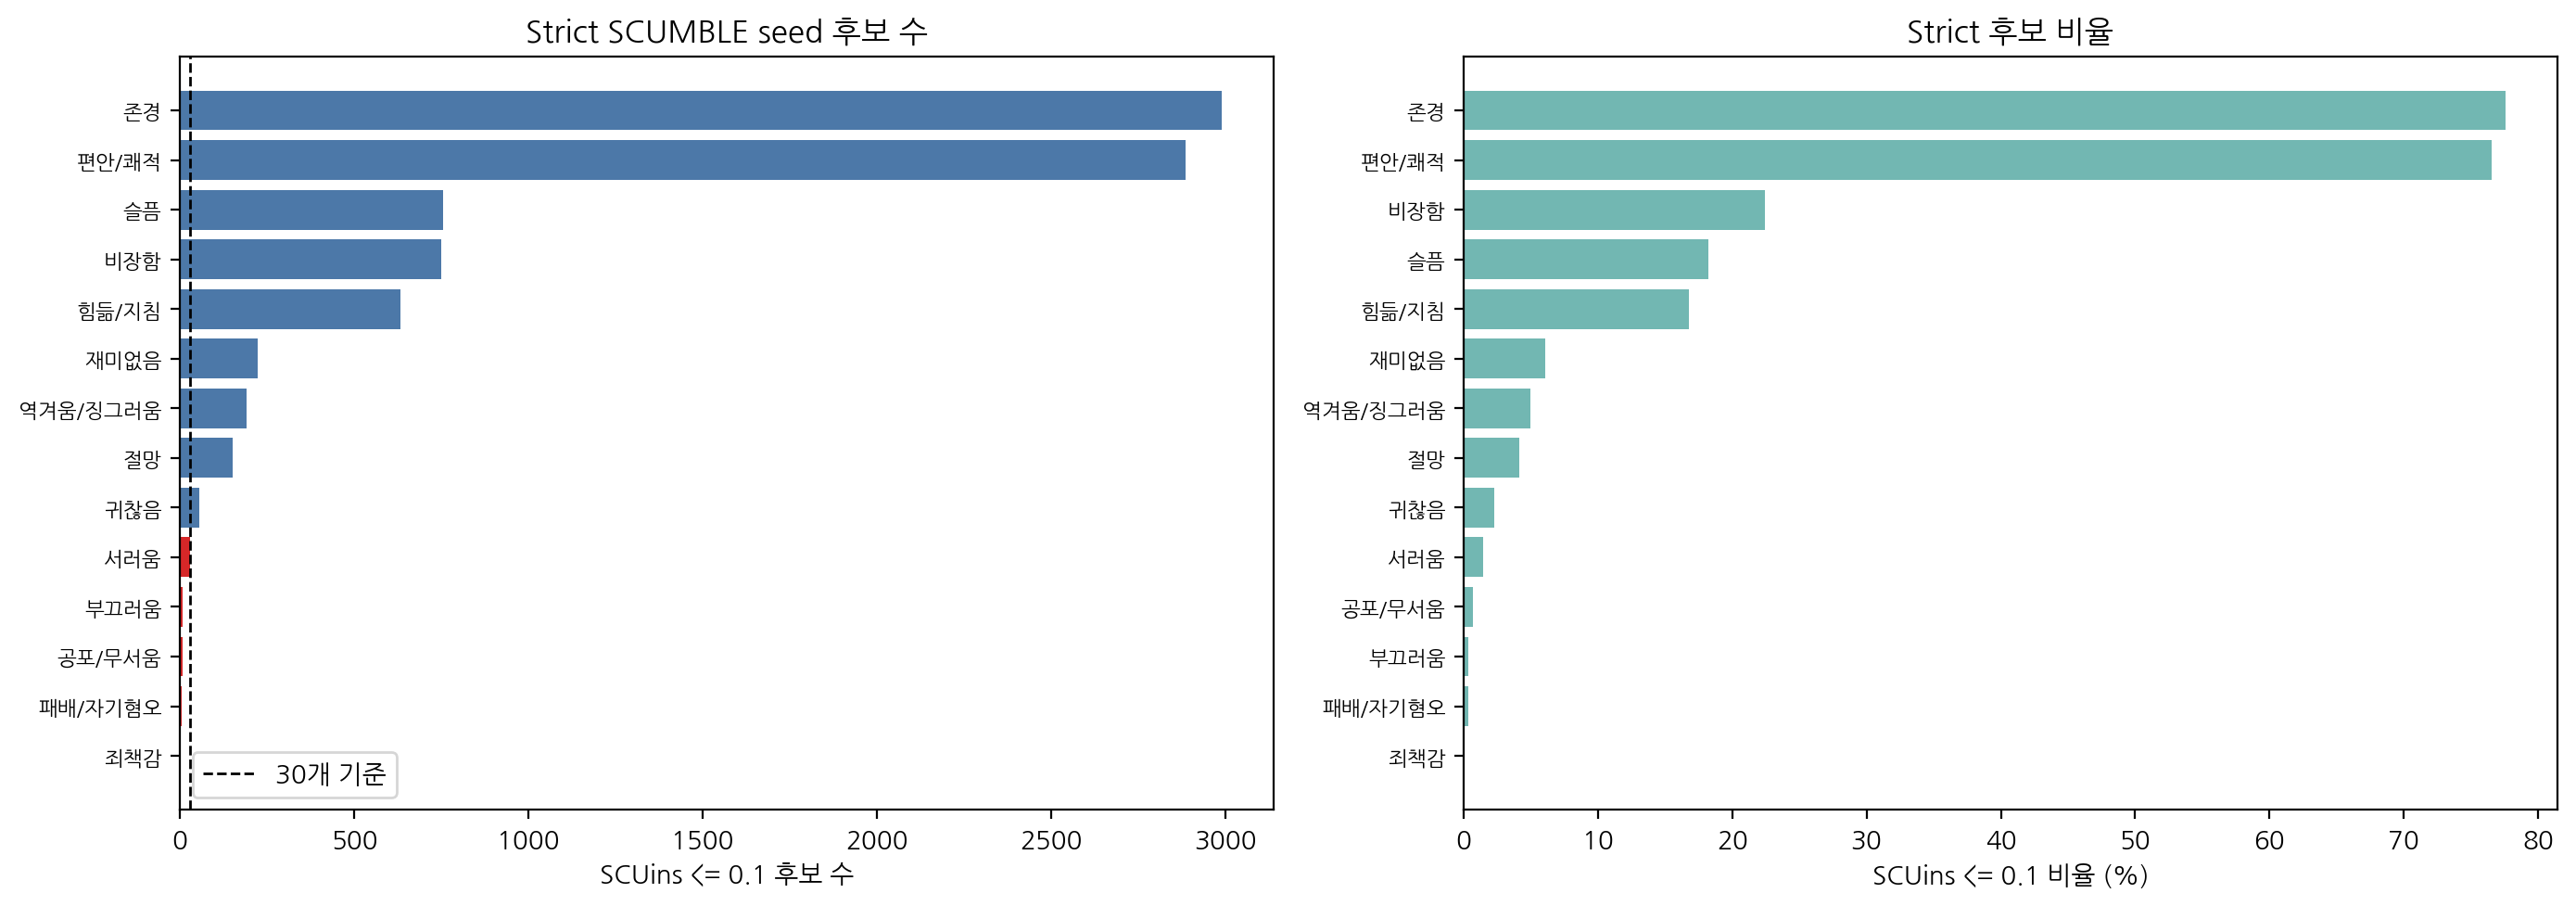

**reference scumble histogram**

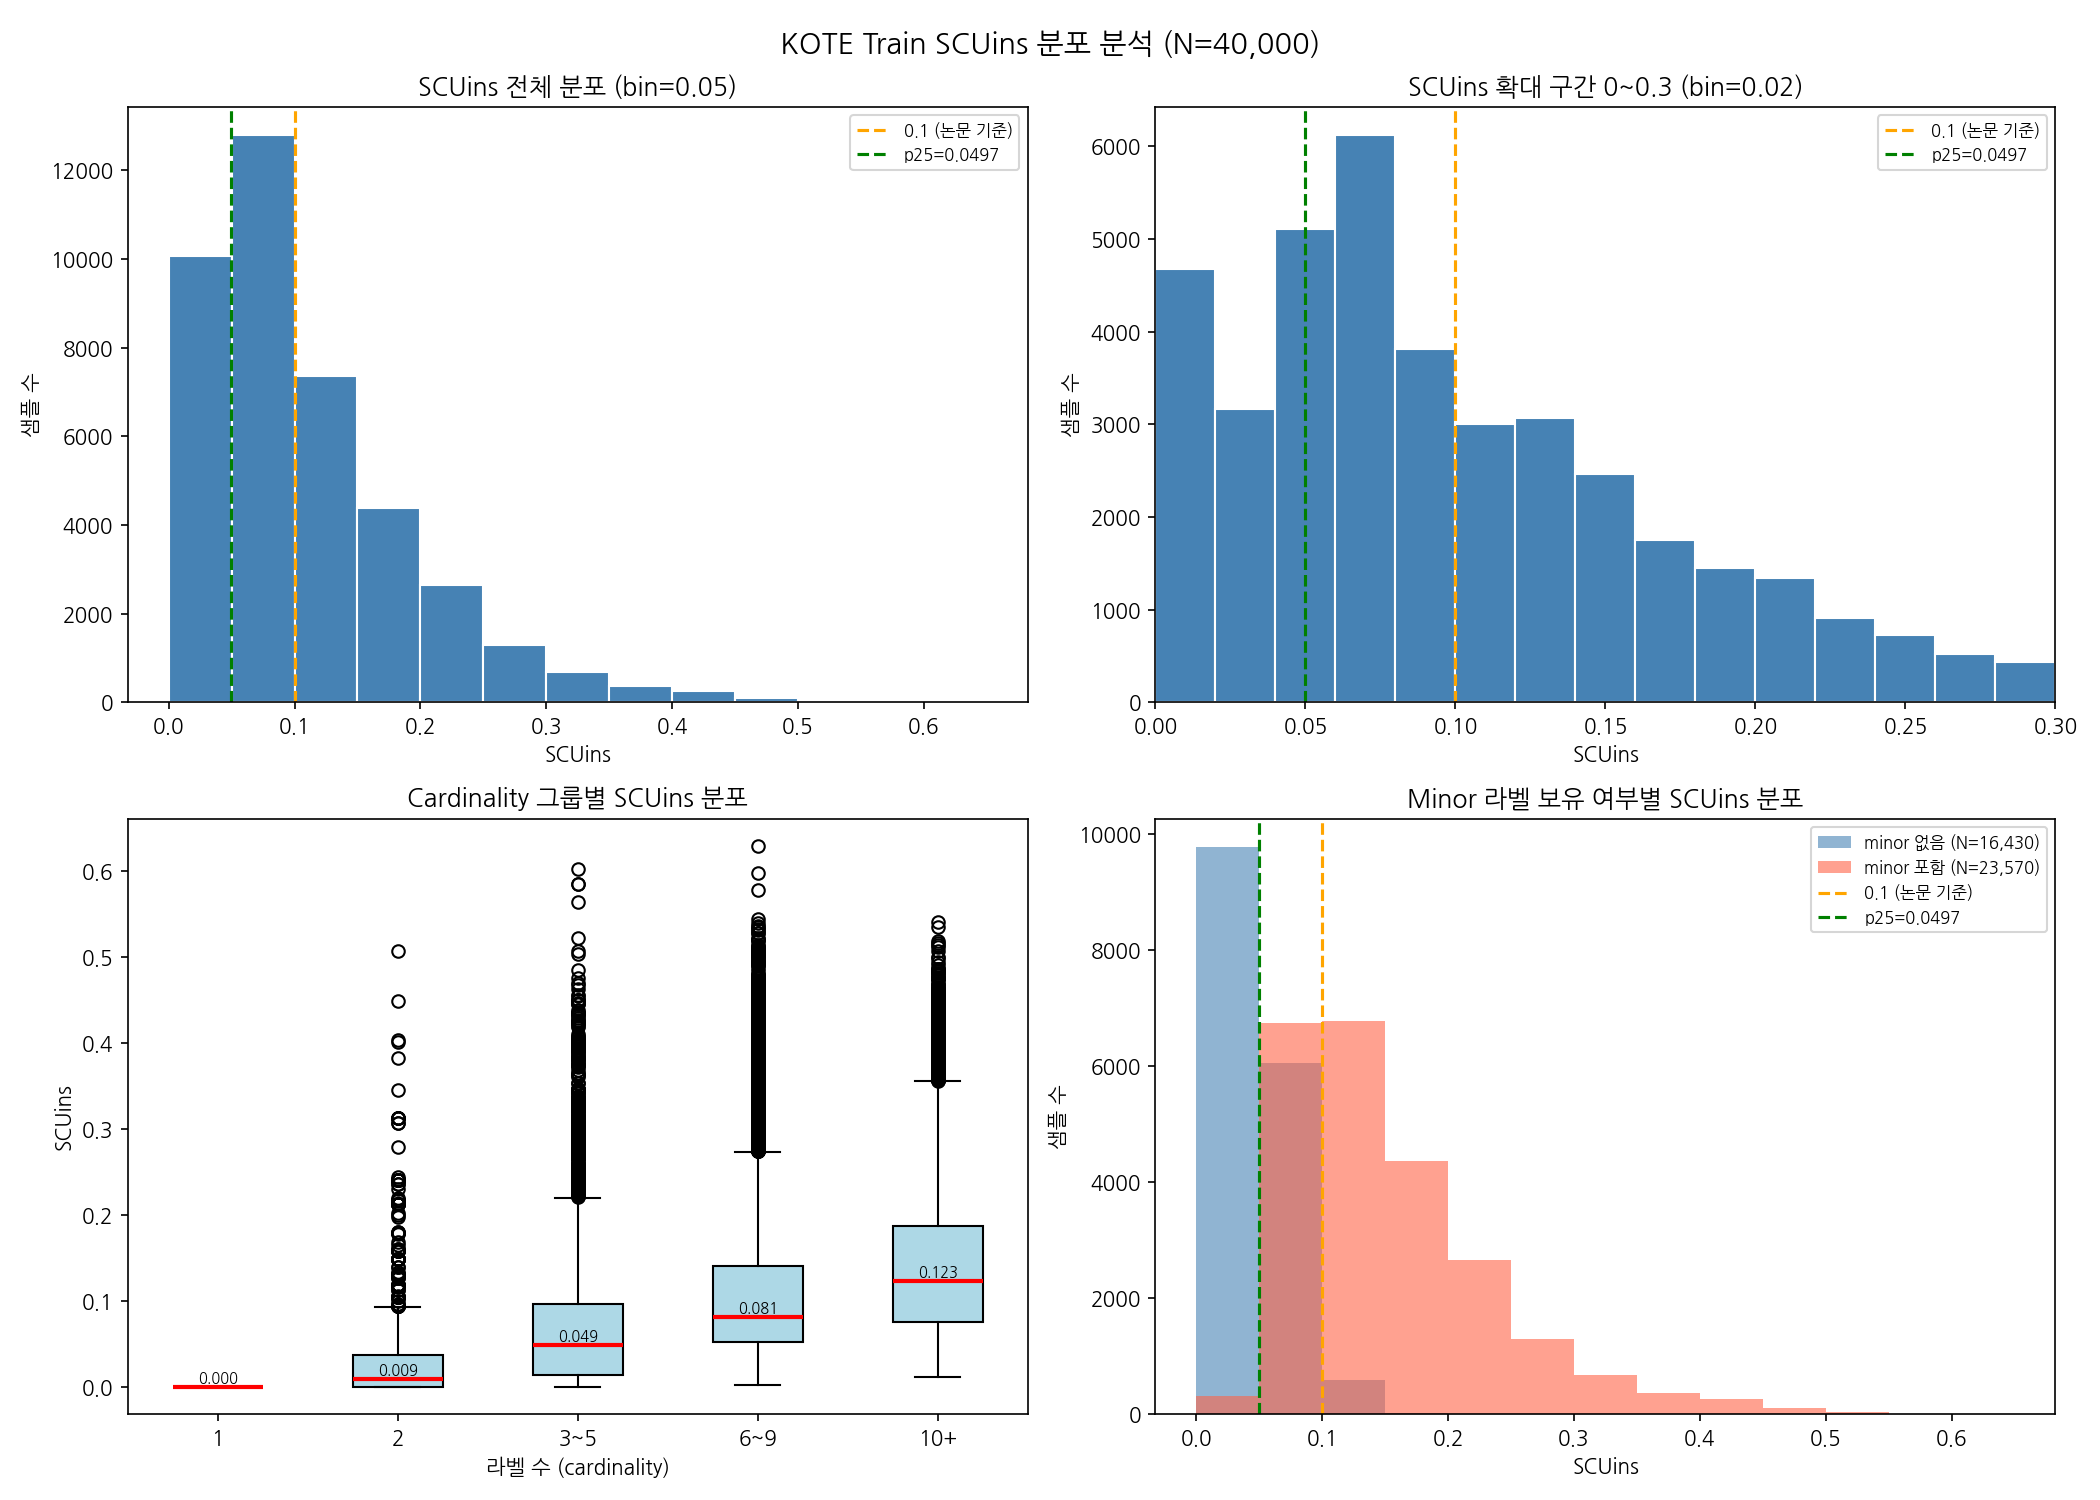

**reference minority SCUins detail**

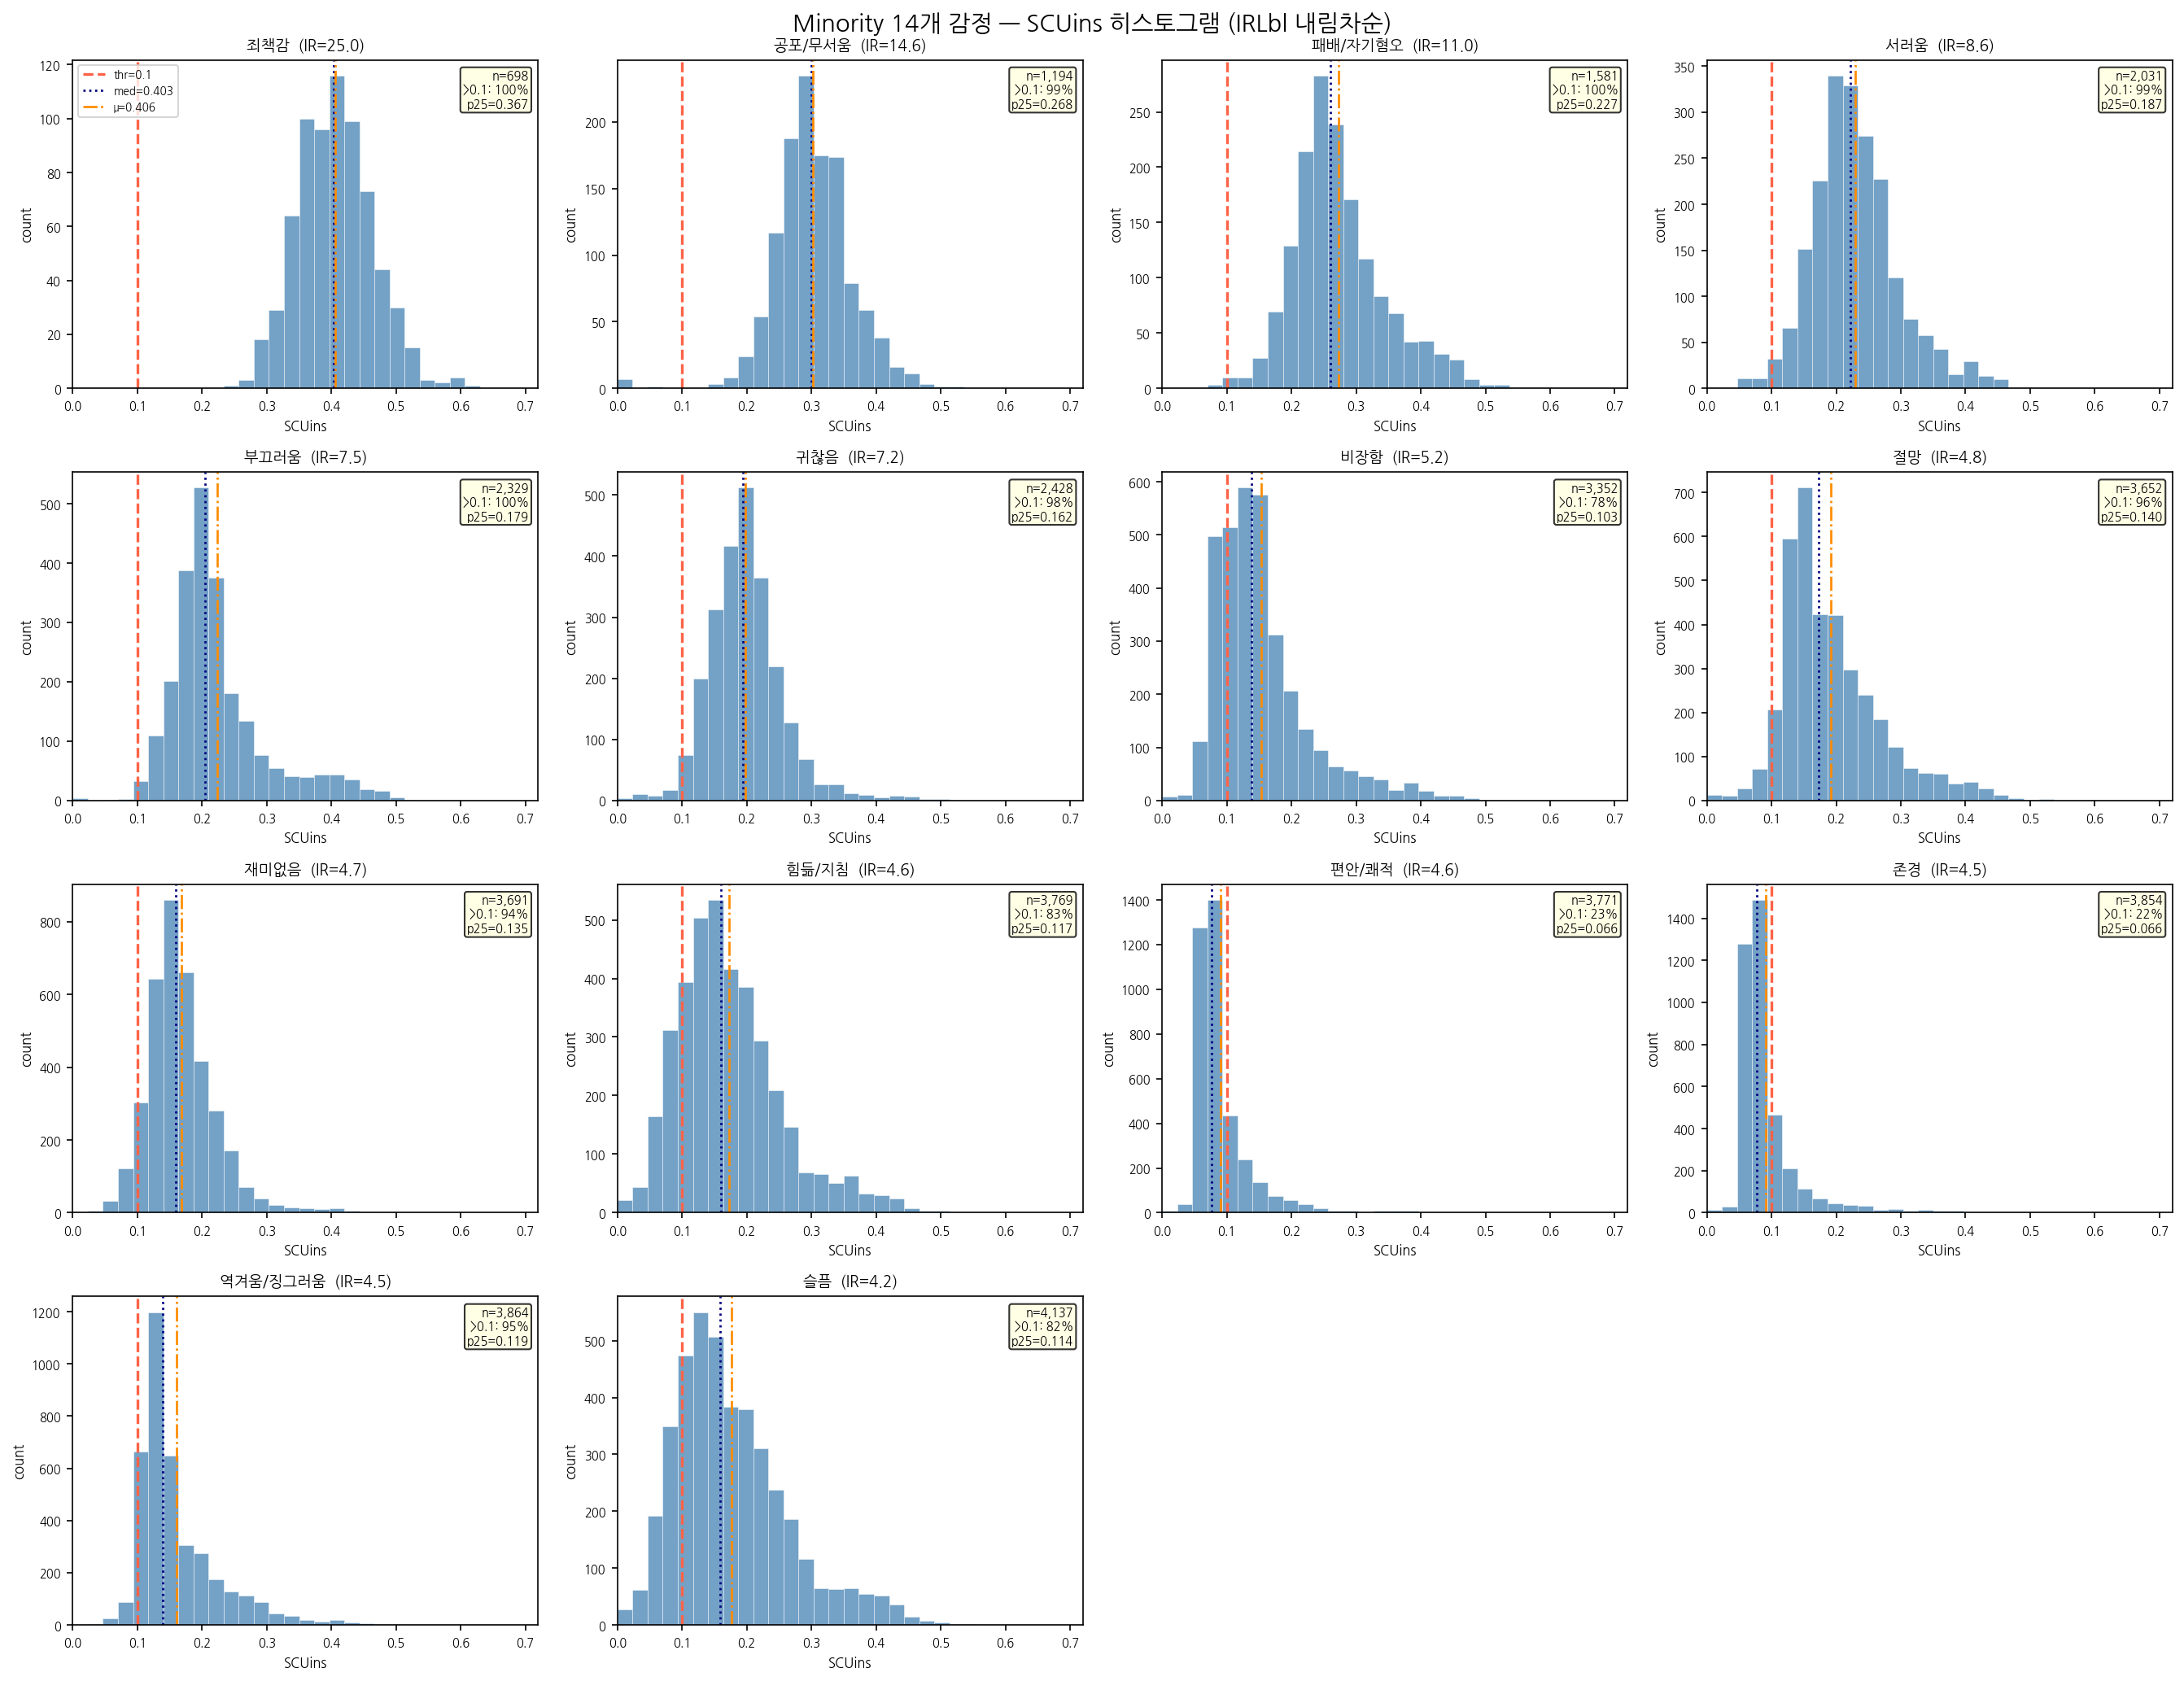

In [9]:
# SCUins/card summary 로드 및 minority별 분포 표 재계산
scumble_path = KOTE_DIR / "scumble_scores.jsonl"
scumble_rows = read_jsonl(scumble_path)

if scumble_rows:
    scumble_df = pd.DataFrame(scumble_rows)
    scumble_df["cardinality_active"] = scumble_df["active_labels"].apply(len)
    scumble_df["has_minor"] = scumble_df["minor_labels_in_sample"].apply(lambda x: bool(x))
    scuins_values = scumble_df["scuins"].astype(float)
    card_values = scumble_df["cardinality_active"].astype(int)

    scuins_summary_df = pd.DataFrame([
        {"metric": "n_samples", "value": len(scumble_df)},
        {"metric": "SCUins mean", "value": round(float(scuins_values.mean()), 6)},
        {"metric": "SCUins median", "value": round(float(scuins_values.median()), 6)},
        {"metric": "SCUins p75", "value": round(float(scuins_values.quantile(0.75)), 6)},
        {"metric": "SCUins max", "value": round(float(scuins_values.max()), 6)},
        {"metric": "card mean", "value": round(float(card_values.mean()), 4)},
        {"metric": "card p30", "value": round(float(card_values.quantile(0.30)), 4)},
        {"metric": "has minority rows", "value": int(scumble_df["has_minor"].sum())},
        {"metric": "SCUins <= 0.1 rows", "value": int((scuins_values <= 0.1).sum())},
    ])
    display(scuins_summary_df)

    label_rows = []
    for label in sorted(minority_labels_from_irlbl, key=lambda x: irlbl_map[x], reverse=True):
        vals = scumble_df[scumble_df["active_label_names"].apply(lambda xs: label in xs)]["scuins"].astype(float)
        label_rows.append({
            "label": label,
            "irlbl": irlbl_map[label],
            "count": label_count[label],
            "strict_n_scuins_le_0_1": int((vals <= 0.1).sum()),
            "strict_ratio_pct": round(float((vals <= 0.1).mean() * 100), 2) if len(vals) else 0,
            "p25": round(float(vals.quantile(0.25)), 6) if len(vals) else None,
            "p50": round(float(vals.quantile(0.50)), 6) if len(vals) else None,
            "p75": round(float(vals.quantile(0.75)), 6) if len(vals) else None,
        })
    minority_scuins_df = pd.DataFrame(label_rows)
    display(minority_scuins_df)
else:
    print(f"[missing or empty] {scumble_path}")

# 기존 figure를 흐름 중에 직접 확인
for title, rel in [
    ("SCUins 전체 분포", "scuins_distribution.png"),
    ("minority SCUins boxplot", "minority_scuins_boxplot_recomputed.png"),
    ("strict 후보 수", "minority_scuins_strict_candidate_counts.png"),
    ("reference scumble histogram", "reference/scumble_histogram.png"),
    ("reference minority SCUins detail", "reference/minority_scuins_detail.png"),
]:
    show_png(FIGURE_DIR / rel, title)

### 4. card & SCUins seed 현황

`aug_seed.csv`는 `data/kote/scumble_scores.jsonl` + `data/kote/irlbl.json`에서 아래 기준으로 라벨당 MeanIR need 수의 seed를 선정한 목록이다.

**need 계산:** `round(n_max / MeanIR − label_count[L])`

**선정 기준 (`strict_card<=6_then_scuins`):**
1. minority 라벨을 포함하는 train 샘플 중 `cardinality_active ≤ 6`인 strict 후보를 추출
2. SCUins 오름차순 정렬 (minority 신호가 지배적인 샘플 우선)
3. strict 후보가 need보다 부족하면 순환 재사용(reuse)으로 채움

`RUN_BUILD_AUG_SEED = True`로 재도출할 수 있다. 기존 `data/aug_seed.csv`를 덮어쓰므로 주의.

In [10]:
# True: scumble_scores.jsonl + irlbl.json에서 seed 재선정 후 data/aug_seed.csv 덮어씀
# False: 기존 data/aug_seed.csv 로드
RUN_BUILD_AUG_SEED = False

if RUN_BUILD_AUG_SEED:
    import csv
    import itertools

    scumble_rows = read_jsonl(KOTE_DIR / "scumble_scores.jsonl")
    irlbl_data = json.loads((KOTE_DIR / "irlbl.json").read_text(encoding="utf-8"))
    n_max = irlbl_data["n_max"]
    mean_ir = irlbl_data["mean_ir"]
    minority_labels_list = irlbl_data["minor_labels"]
    label_count_map = irlbl_data["label_count"]
    irlbl_map_local = irlbl_data["irlbl"]

    need_map = {
        L: max(0, round(n_max / mean_ir - label_count_map[L]))
        for L in minority_labels_list
    }

    CARD_THRESHOLD = 6
    FIELDS = [
        "label", "irlbl", "need", "seed_idx", "seed_sample_id", "seed_text",
        "reuse_round", "source_labels", "active_labels", "card", "scuins",
        "selection_rule", "selection_rank", "origin",
    ]

    out_rows = []
    for label in sorted(minority_labels_list, key=lambda x: -need_map.get(x, 0)):
        need = need_map[label]
        if need <= 0:
            continue

        strict = [
            r for r in scumble_rows
            if label in r.get("active_label_names", [])
            and r.get("cardinality_active", 99) <= CARD_THRESHOLD
        ]
        strict.sort(key=lambda r: r["scuins"])
        n_unique = len(strict)

        if n_unique == 0:
            print(f"[WARN] {label}: strict 후보 없음, 건너뜀")
            continue

        rule = (
            "strict_card<=6_then_scuins"
            if n_unique >= need
            else f"strict_card<=6_then_scuins+reuse_strict_candidates(unique={n_unique})"
        )
        candidates = list(itertools.islice(itertools.cycle(strict), need))

        seen_ids: dict[int, int] = {}
        for idx, r in enumerate(candidates):
            sid = r["sample_id"]
            reuse_round = seen_ids.get(sid, 0)
            seen_ids[sid] = reuse_round + 1
            active_names = r.get("active_label_names", [])
            out_rows.append({
                "label": label,
                "irlbl": round(irlbl_map_local[label], 6),
                "need": need,
                "seed_idx": idx + 1,
                "seed_sample_id": sid,
                "seed_text": r.get("text", ""),
                "reuse_round": reuse_round,
                "source_labels": "|".join(active_names),
                "active_labels": "|".join(active_names),
                "card": r.get("cardinality_active", ""),
                "scuins": r.get("scuins", ""),
                "selection_rule": rule,
                "selection_rank": (idx % n_unique) + 1,
                "origin": "kote_train",
            })

    out_path = DATA_DIR / "aug_seed.csv"
    with out_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDS)
        writer.writeheader()
        writer.writerows(out_rows)
    print(f"[OK] aug_seed.csv 재생성: {len(out_rows):,} rows → {out_path.relative_to(ROOT_DIR)}")
else:
    print("[SKIP] RUN_BUILD_AUG_SEED=False: 기존 data/aug_seed.csv 로드")

[SKIP] RUN_BUILD_AUG_SEED=False: 기존 data/aug_seed.csv 로드


,label,meanir_need,irlbl,selected_unique_n,reused_seed_rows,card_median,card_max,scuins_median,scuins_max,seed_count,count_ok
0,죄책감,3609,25.021490,68,3541,5.0,6,0.453730,0.628702,3609,True
1,공포/무서움,3113,14.627303,225,2888,5.0,6,0.325668,0.474912,3113,True
2,패배/자기혐오,2726,11.046806,135,2591,5.0,6,0.266478,0.462244,2726,True
3,서러움,2276,8.599212,237,2039,6.0,6,0.219489,0.431814,2276,True
4,부끄러움,1978,7.498927,216,1762,5.0,6,0.215015,0.506887,1978,True
5,귀찮음,1879,7.193163,446,1433,5.0,6,0.201873,0.521104,1879,True
6,비장함,955,5.210322,819,136,5.0,6,0.110932,0.530797,955,True
7,절망,655,4.782311,391,264,5.0,6,0.144211,0.470610,655,True
8,재미없음,616,4.731780,616,0,6.0,6,0.169903,0.194227,616,True
9,힘듦/지침,538,4.633855,538,0,5.0,6,0.117464,0.256750,538,True


seed rows: 19,947
expected MeanIR need total: 19,947
all label counts ok: True
duplicate (label, seed_sample_id, seed_idx): 0
selection rules: 10


,selection_rule,rows
0,strict_card<=6_then_scuins+reuse_strict_candid...,3609
1,strict_card<=6_then_scuins+reuse_strict_candid...,3113
2,strict_card<=6_then_scuins+reuse_strict_candid...,2726
3,strict_card<=6_then_scuins,2313
4,strict_card<=6_then_scuins+reuse_strict_candid...,2276
5,strict_card<=6_then_scuins+reuse_strict_candid...,1978
6,strict_card<=6_then_scuins+reuse_strict_candid...,1879
7,strict_card<=6_then_scuins+reuse_strict_candid...,955
8,strict_card<=6_then_scuins+reuse_strict_candid...,655
9,strict_card<=6_then_scuins+reuse_strict_candid...,443


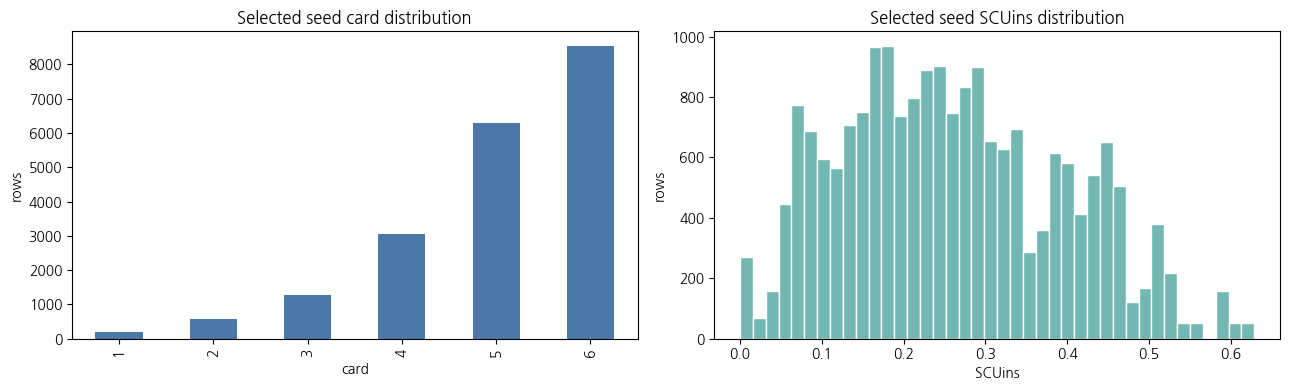

In [11]:
# aug_seed.csv 검증 및 seed 현황 요약
seed_csv = DATA_DIR / "aug_seed.csv"
seed_df = pd.read_csv(seed_csv)

seed_counts = seed_df["label"].value_counts().rename_axis("label").reset_index(name="seed_count")
need_df = seed_df.groupby("label", as_index=False).agg(
    meanir_need=("need", "first"),
    irlbl=("irlbl", "first"),
    selected_unique_n=("seed_sample_id", "nunique"),
    reused_seed_rows=("reuse_round", lambda s: int((s.astype(int) > 0).sum())),
    card_median=("card", "median"),
    card_max=("card", "max"),
    scuins_median=("scuins", "median"),
    scuins_max=("scuins", "max"),
)
seed_check_df = need_df.merge(seed_counts, on="label", how="left")
seed_check_df["count_ok"] = seed_check_df["meanir_need"].astype(int) == seed_check_df["seed_count"].astype(int)
seed_check_df = seed_check_df.sort_values("irlbl", ascending=False).reset_index(drop=True)

display(seed_check_df)
print(f"seed rows: {len(seed_df):,}")
print(f"expected MeanIR need total: {int(seed_df['need'].groupby(seed_df['label']).first().sum()):,}")
print(f"all label counts ok: {bool(seed_check_df['count_ok'].all())}")
print(f"duplicate (label, seed_sample_id, seed_idx): {int(seed_df.duplicated(['label', 'seed_sample_id', 'seed_idx']).sum())}")
print(f"selection rules: {seed_df['selection_rule'].nunique()}")

display(seed_df["selection_rule"].value_counts().rename_axis("selection_rule").reset_index(name="rows"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
seed_df["card"].astype(int).value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Selected seed card distribution")
axes[0].set_xlabel("card")
axes[0].set_ylabel("rows")
axes[1].hist(seed_df["scuins"].astype(float), bins=40, color="#72b7b2", edgecolor="white")
axes[1].set_title("Selected seed SCUins distribution")
axes[1].set_xlabel("SCUins")
axes[1].set_ylabel("rows")
plt.tight_layout()
plt.show()

### 5. 증강 산출물, 필터, repair 현황

각 증강 파일의 실제 row 수와 필터/repair 보고서를 함께 확인한다. 여기서도 실행하지 않은 검증 조건은 사용한 것처럼 말하지 않는다.

In [12]:
# 증강 산출물 count + report 확인
artifact_rows = [
    {"condition": "total_seed_gemini_aug", "path": total_seed_aug_jsonl, "rows": count_jsonl(total_seed_aug_jsonl)},
    {"condition": "back_translation_raw", "path": AUG_DIR / "bt" / "aug_bt_need19947_s42.jsonl", "rows": count_jsonl(AUG_DIR / "bt" / "aug_bt_need19947_s42.jsonl")},
    {"condition": "back_translation_repaired", "path": AUG_DIR / "bt" / "aug_bt_need19947_s42_repaired.jsonl", "rows": count_jsonl(AUG_DIR / "bt" / "aug_bt_need19947_s42_repaired.jsonl")},
    {"condition": "card_scuins_raw", "path": AUG_DIR / "card_scuins" / "aug_card_scuins_meanir_raw.jsonl", "rows": count_jsonl(AUG_DIR / "card_scuins" / "aug_card_scuins_meanir_raw.jsonl")},
    {"condition": "card_scuins_filtered", "path": AUG_DIR / "card_scuins" / "aug_card_scuins_meanir.jsonl", "rows": count_jsonl(AUG_DIR / "card_scuins" / "aug_card_scuins_meanir.jsonl")},
]
artifact_df = pd.DataFrame([{**r, "path": str(r["path"].relative_to(ROOT_DIR))} for r in artifact_rows])
display(artifact_df)

card_filtered_rows = read_jsonl(AUG_DIR / "card_scuins" / "aug_card_scuins_meanir.jsonl")
if card_filtered_rows:
    card_label_counts = Counter(r.get("target_label") or (r.get("labels") or [None])[0] for r in card_filtered_rows)
    display(pd.DataFrame(card_label_counts.most_common(), columns=["target_label", "filtered_count"]))

bt_report_path = AUG_DIR / "bt" / "aug_bt_need19947_s42_repaired.report.json"
if bt_report_path.exists():
    display(Markdown("**BT repair report**"))
    display(json.loads(bt_report_path.read_text(encoding="utf-8")))

card_fill_report_path = AUG_DIR / "card_scuins" / "aug_card_scuins_meanir_raw.fill_missing_report.json"
if card_fill_report_path.exists():
    display(Markdown("**card/SCUins missing fill report**"))
    display(json.loads(card_fill_report_path.read_text(encoding="utf-8")))

filter_report_path = REPORT_DIR / "filter_report.md"
if filter_report_path.exists():
    display(Markdown("**filter_report.md excerpt**"))
    print("\n".join(filter_report_path.read_text(encoding="utf-8").splitlines()[:40]))
else:
    print(f"[missing] {filter_report_path.relative_to(ROOT_DIR)}")

,condition,path,rows
0,total_seed_gemini_aug,data/augmented/total_seed_gemini_aug/total_see...,19947
1,back_translation_raw,data/augmented/bt/aug_bt_need19947_s42.jsonl,19947
2,back_translation_repaired,data/augmented/bt/aug_bt_need19947_s42_repaire...,19947
3,card_scuins_raw,data/augmented/card_scuins/aug_card_scuins_mea...,19947
4,card_scuins_filtered,data/augmented/card_scuins/aug_card_scuins_mea...,19734


,target_label,filtered_count
0,죄책감,3584
1,공포/무서움,3048
2,패배/자기혐오,2723
3,서러움,2264
4,부끄러움,1958
5,귀찮음,1869
6,비장함,948
7,절망,643
8,재미없음,607
9,힘듦/지침,533


**BT repair report**

{'target': 19947,
 'output_rows': 19947,
 'kept_from_input': 7440,
 'regenerated': 12507,
 'input_reject_reasons': {'known_broken_phrase': 3105,
  'latin_dominant': 5788,
  'too_few_korean_chars': 2300,
  'repeated_chunk': 371,
  'han_chars': 116,
  'too_few_words': 469,
  'too_long': 79,
  'empty_text': 70,
  'low_unique_word_ratio': 209},
 'regeneration_reject_reasons': {'known_broken_phrase': 8101,
  'latin_dominant': 13127,
  'too_few_korean_chars': 5249,
  'too_few_words': 907,
  'too_few_latin_chars': 15,
  'han_chars': 446},
 'exhausted_candidates': 0,
 'input': 'data/augmented/bt/aug_bt_need19947_s42.jsonl',
 'output': 'data/augmented/bt/aug_bt_need19947_s42_repaired.jsonl',
 'status': 'complete'}

**card/SCUins missing fill report**

{'seed_rows': 19947,
 'final_raw_rows': 19947,
 'missing_before': 20,
 'added': 20,
 'failed': 0,
 'failed_items': []}

**filter_report.md excerpt**

# filter_report.md - card/SCUins 기본 품질 필터 결과

| 단계 | 입력 | 제거 | 출력 |
|---|---:|---:|---:|
| 최소 길이/한글 수(min_tokens=5, min_korean=8) | 19,947 | 213 | 19,734 |
| Exact dedup | 19,734 | 0 | 19,734 |


In [13]:
# 4. 문서 리포트 재생성: 실제 존재하는 산출물 기준으로만 작성한다.
if RUN_REBUILD_REPORTS:
    subprocess.run(
        [sys.executable, str(SCRIPTS_DIR / "build_reports.py"), "--root", str(ROOT_DIR)],
        cwd=str(ROOT_DIR),
        check=True,
    )
else:
    print("[SKIP] report rebuild")

for rel in ["data/kote_intro.md", "data/aug_strategy.md", "results/report/model_report.md", "results/comparision.md"]:
    print(ROOT_DIR / rel)

[OK] reports generated
/home/user/projects1/pjh/lab-w18/dl-prac-submission/data/kote_intro.md
/home/user/projects1/pjh/lab-w18/dl-prac-submission/data/aug_strategy.md
/home/user/projects1/pjh/lab-w18/dl-prac-submission/results/report/model_report.md
/home/user/projects1/pjh/lab-w18/dl-prac-submission/results/comparision.md


## Baseline

원본 KOTE train만 사용한다. `results/model/baseline_th03/metrics.json`은 epoch 10 결과를 담고 있다. `RUN_BASELINE_FINETUNE=True`일 때만 GPU 학습을 다시 수행한다.


In [14]:
def load_metrics(run_name):
    path = MODEL_DIR / run_name / "metrics.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def run_finetune_script(run_name, aug_jsonl=None, overwrite=False):
    cmd = [
        sys.executable, str(SCRIPTS_DIR / "finetune.py"),
        "--root", str(ROOT_DIR),
        "--run-name", run_name,
        "--epochs", str(EPOCHS),
        "--batch-size", str(BATCH_SIZE),
        "--threshold", str(THRESHOLD),
        "--seed", str(SEED),
    ]
    if aug_jsonl:
        cmd += ["--aug-jsonl", str(aug_jsonl)]
    if overwrite:
        cmd += ["--overwrite"]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=str(ROOT_DIR), check=True)

if RUN_BASELINE_FINETUNE:
    run_finetune_script("baseline_th03", overwrite=True)

baseline = load_metrics("baseline_th03")
print(json.dumps({
    "run": "baseline_th03",
    "f1_macro": baseline.get("f1_macro") if baseline else None,
    "f1_micro": baseline.get("f1_micro") if baseline else None,
    "guilt_f1": baseline.get("per_label", {}).get("죄책감") if baseline else None,
}, ensure_ascii=False, indent=2))

{
  "run": "baseline_th03",
  "f1_macro": 0.5586952018525216,
  "f1_micro": 0.6530354869974427,
  "guilt_f1": 0.022988505747126436
}


## total_seed_gemini_aug

MeanIR 기준 minority 대상 Gemini paraphrase 산출물이다. lab-w10/exp_aug에서 생성된 파일을 그대로 사용하며, API 재호출은 `RUN_AUG_GEMINI_GENERATION=True`일 때만 수행한다.

In [15]:
total_seed_gemini_aug_jsonl = AUG_DIR / "total_seed_gemini_aug" / "total_seed_gemini_aug_meanir.jsonl"
total_seed_gemini_aug_json = AUG_DIR / "total_seed_gemini_aug" / "augmented_data_meanir_gemini.json"

if RUN_AUG_GEMINI_GENERATION:
    if not os.environ.get("GEMINI_API_KEY"):
        raise RuntimeError("GEMINI_API_KEY가 필요합니다. ROOT_DIR/.env에 설정하세요.")
    subprocess.run([sys.executable, str(SCRIPTS_DIR / "generate_total_seed_gemini_meanir.py")], cwd=str(ROOT_DIR), check=True)
else:
    print("[SKIP] RUN_AUG_GEMINI_GENERATION=False")

if RUN_AUG_GEMINI_FINETUNE:
    run_finetune_script("total_seed_gemini_aug_meanir", aug_jsonl=total_seed_gemini_aug_jsonl, overwrite=True)
else:
    existing = load_metrics("total_seed_gemini_aug_meanir")
    print("total_seed_gemini_aug_meanir metrics:", "exists" if existing else "not found; 기존 비교 JSON은 results/report/total_seed_gemini_aug_results_comparison.json 참조")

[SKIP] RUN_AUG_GEMINI_GENERATION=False
total_seed_gemini_aug_meanir metrics: not found; 기존 비교 JSON은 results/report/total_seed_gemini_aug_results_comparison.json 참조


## Back Translation 비교군

ko->en->ko 역번역 비교군이다. raw 생성, repair, fine-tuning을 각각 분리했다. 기본 상태에서는 `data/augmented/bt/aug_bt_need19947_s42_repaired.jsonl`과 epoch 10 metrics를 로드한다.


In [16]:
bt_raw = AUG_DIR / "bt" / "aug_bt_need19947_s42.jsonl"
bt_repaired = AUG_DIR / "bt" / "aug_bt_need19947_s42_repaired.jsonl"

if RUN_BT_GENERATION:
    subprocess.run([
        sys.executable, str(SCRIPTS_DIR / "generate_back_translation.py"),
        "--out", bt_raw.name,
        "--max-samples", "19947",
        "--sample-mode", "minority",
        "--seed", str(SEED),
    ], cwd=str(ROOT_DIR), check=True)
else:
    print("[SKIP] RUN_BT_GENERATION=False")

if RUN_BT_REPAIR:
    subprocess.run([
        sys.executable, str(SCRIPTS_DIR / "repair_back_translation.py"),
        "--input", bt_raw.name,
        "--out", bt_repaired.name,
        "--target", "19947",
        "--sample-mode", "minority",
        "--seed", str(SEED),
        "--overwrite",
    ], cwd=str(ROOT_DIR), check=True)
else:
    print("[SKIP] RUN_BT_REPAIR=False")

if RUN_BT_FINETUNE:
    run_finetune_script("aug_bt_need19947_s42_repaired", aug_jsonl=bt_repaired, overwrite=True)

bt_metrics = load_metrics("aug_bt_need19947_s42_repaired")
print(json.dumps({
    "run": "aug_bt_need19947_s42_repaired",
    "f1_macro": bt_metrics.get("f1_macro") if bt_metrics else None,
    "f1_micro": bt_metrics.get("f1_micro") if bt_metrics else None,
    "guilt_f1": bt_metrics.get("per_label", {}).get("죄책감") if bt_metrics else None,
}, ensure_ascii=False, indent=2))

[SKIP] RUN_BT_GENERATION=False
[SKIP] RUN_BT_REPAIR=False
{
  "run": "aug_bt_need19947_s42_repaired",
  "f1_macro": 0.5611171447227383,
  "f1_micro": 0.6499242605437295,
  "guilt_f1": 0.09803921568627451
}


## card & SCUins

MeanIR need는 유지하되 `aug_seed.csv`의 card/SCUins seed를 사용한다. raw 19,947건을 생성한 뒤 기본 품질 필터를 거쳐 19,734건을 학습에 사용했다. `results/model/aug_card_scuins_meanir/metrics.json`은 epoch 10 결과다.


In [17]:
card_raw = AUG_DIR / "card_scuins" / "aug_card_scuins_meanir_raw.jsonl"
card_filtered = AUG_DIR / "card_scuins" / "aug_card_scuins_meanir.jsonl"

if RUN_CARD_SCUINS_GENERATION:
    if not os.environ.get("GEMINI_API_KEY"):
        raise RuntimeError("GEMINI_API_KEY가 필요합니다. ROOT_DIR/.env에 설정하세요.")
    subprocess.run([
        sys.executable, str(SCRIPTS_DIR / "generate_card_scuins.py"),
        "--root", str(ROOT_DIR),
        "--seed-csv", "data/aug_seed.csv",
        "--output", str(card_raw.relative_to(ROOT_DIR)),
        "--resume",
    ], cwd=str(ROOT_DIR), check=True)
else:
    print("[SKIP] RUN_CARD_SCUINS_GENERATION=False")

if RUN_CARD_SCUINS_FILTER:
    subprocess.run([
        sys.executable, str(SCRIPTS_DIR / "filter_card_scuins.py"),
        "--root", str(ROOT_DIR),
        "--input", str(card_raw.relative_to(ROOT_DIR)),
        "--output", str(card_filtered.relative_to(ROOT_DIR)),
        "--report", "results/report/filter_report.md",
    ], cwd=str(ROOT_DIR), check=True)
else:
    print("[SKIP] RUN_CARD_SCUINS_FILTER=False")

if RUN_CARD_SCUINS_FINETUNE:
    run_finetune_script("aug_card_scuins_meanir", aug_jsonl=card_filtered, overwrite=True)

card_metrics = load_metrics("aug_card_scuins_meanir")
card_ckpt = MODEL_DIR / "aug_card_scuins_meanir" / "ckpt" / "best.ckpt"
print(json.dumps({
    "run": "aug_card_scuins_meanir",
    "metrics_exists": card_metrics is not None,
    "checkpoint_exists": card_ckpt.exists(),
    "f1_macro": card_metrics.get("f1_macro") if card_metrics else None,
    "f1_micro": card_metrics.get("f1_micro") if card_metrics else None,
    "guilt_f1": card_metrics.get("per_label", {}).get("죄책감") if card_metrics else None,
}, ensure_ascii=False, indent=2))

[SKIP] RUN_CARD_SCUINS_GENERATION=False
[SKIP] RUN_CARD_SCUINS_FILTER=False
{
  "run": "aug_card_scuins_meanir",
  "metrics_exists": true,
  "checkpoint_exists": true,
  "f1_macro": 0.5677731483790877,
  "f1_micro": 0.6501413300143075,
  "guilt_f1": 0.17142857142857143
}


## 최종 비교와 백엔드 연결 메모

`results/comparision.md`, `results/report/model_report.md`, `results/single_condition_comparison_e10.csv`를 확인한다. 백엔드 모델 로딩은 `backend/app/inference/model_loader.py`, 추론은 `backend/app/inference/predict.py`가 담당한다. 최종 F1-macro 기준 모델은 card & SCUins epoch 10 결과이며, 백엔드 실행 시 `MODEL_PATH=results/model/aug_card_scuins_meanir/ckpt`처럼 `.ckpt`가 들어 있는 디렉토리를 가리키게 둔다.


In [18]:
# 5. 최종 비교 리포트 미리보기
if RUN_REBUILD_REPORTS:
    subprocess.run([sys.executable, str(SCRIPTS_DIR / "build_reports.py"), "--root", str(ROOT_DIR)], cwd=str(ROOT_DIR), check=True)

for rel in ["results/comparision.md", "results/report/model_report.md"]:
    path = ROOT_DIR / rel
    print(f"\n===== {rel} =====")
    if path.exists():
        print("\n".join(path.read_text(encoding="utf-8").splitlines()[:100]))
    else:
        print("missing")

comparison_csv = ROOT_DIR / "results" / "single_condition_comparison_e10.csv"
if comparison_csv.exists():
    print(f"\n===== {comparison_csv.relative_to(ROOT_DIR)} =====")
    print(comparison_csv.read_text(encoding="utf-8-sig"))

summary_json = ROOT_DIR / "results" / "augmentation_summary_e10.json"
if summary_json.exists():
    print(f"\n===== {summary_json.relative_to(ROOT_DIR)} =====")
    summary = json.loads(summary_json.read_text(encoding="utf-8"))
    print(json.dumps({"best_condition": summary.get("best_condition_including_reference"), "policy": summary.get("comparison_policy")}, ensure_ascii=False, indent=2))

print("\nBackend model modules:")
print(ROOT_DIR / "backend/app/inference/model_loader.py")
print(ROOT_DIR / "backend/app/inference/predict.py")
print("Suggested MODEL_PATH:", ROOT_DIR / "results/model/aug_card_scuins_meanir/ckpt")


[OK] reports generated

===== results/comparision.md =====
# 증강 조건 비교

baseline, Back Translation, card & SCUins는 epoch 10 기준으로 맞춰 재평가했다. `total_seed_gemini_aug`는 저장된 기존 참고 결과다.

| 조건 | F1-macro | Δ macro vs baseline_e10 | F1-micro | 죄책감 F1 | 근거 |
|---|---:|---:|---:|---:|---|
| baseline_e10 | 0.5587 | 0.0000 | 0.6530 | 0.0230 | epoch 10 metrics |
| total_seed_gemini_aug | 0.5617 | 0.0030 | 0.6481 | - | 기존 비교 JSON, epoch 10 재학습 아님 |
| back_translation_e10 | 0.5611 | 0.0024 | 0.6499 | 0.0980 | BT repaired 19,947, epoch 10 metrics |
| card_scuins_e10 | 0.5678 | 0.0091 | 0.6501 | 0.1714 | card & SCUins filtered 19,734, epoch 10 metrics |

## 해석 메모

- epoch 10 기준 F1-macro는 card & SCUins가 가장 높다.
- card & SCUins는 baseline 대비 macro F1을 개선했지만 micro F1은 baseline보다 낮아, 빈도 중심 전체 성능보다 라벨 균형 관점의 개선으로 해석한다.
- BT도 baseline 대비 macro F1은 소폭 개선하지만 card & SCUins보다 개선 폭이 작다.
- aug_gemini는 epoch 10으로 재학습한 결과가 아니므로 참고 비교군으로만 둔다.

===== results/report/model_report.md =====
# 모델 결과 리포트

최종 test 지표는 각 `results

## 뉴스 수집 및 백엔드 연동 흐름 점검

이 구간은 `backend/`와 `app/` 원본 파일을 수정하지 않고, 백엔드 모듈을 노트북에서 직접 호출해 RSS/Naver API 수집, 전처리, SQLite DB 저장, 로컬 모델 추론 저장 흐름을 소량으로 확인한다. 실제 서비스 서버에서는 같은 DB 스키마와 `backend/app/inference` 모듈을 사용한다.


In [19]:
# 6. 뉴스 수집/DB/추론 테스트 플래그
# RUN_NEWS_RSS_FETCH / RUN_NEWS_DB_INSERT 는 True 로 두어 실행 흐름을 기록한다.
# Naver API 키가 없으면 RUN_NEWS_NAVER_FETCH 는 False 유지.
# 추론 결과는 이미 DB 에 98,380 건 저장돼 있으므로 RUN_NEWS_INFERENCE 는 False.

RUN_NEWS_RSS_FETCH = True   # True: RSS 피드에서 기사 수집 / False: 새 수집 없이 기존 DB 내용만 조회
RUN_NEWS_NAVER_FETCH = False # True: Naver Search API로 기사 수집 (NAVER_CLIENT_ID, NAVER_CLIENT_SECRET 필요) / False: 새 수집 없이 기존 DB 내용만 조회
RUN_NEWS_DB_INSERT = True   # True: 수집한 record를 backend/data/news.db (headlines 테이블) 에 삽입 / False: DB 삽입 없이 기존 headlines 조회만 수행
RUN_NEWS_INFERENCE = False  # True: 미처리 headline에 대해 emotion_results 추론·저장 (MODEL_PATH 의 best.ckpt 필요) / False: 이미 저장된 추론 결과만 조회

NEWS_RSS_MAX_ITEMS = 30
NEWS_NAVER_QUERIES = ["정치", "경제", "사회"]
NEWS_NAVER_DISPLAY = 10
NEWS_MODEL_RUN = "aug_card_scuins_meanir"

BACKEND_DIR = ROOT_DIR / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

try:
    from dotenv import load_dotenv
    load_dotenv(ROOT_DIR / ".env")
except Exception:
    pass

os.environ.setdefault("MODEL_PATH", str((MODEL_DIR / NEWS_MODEL_RUN / "ckpt").resolve()))
print("backend dir:", BACKEND_DIR.relative_to(ROOT_DIR))
print("MODEL_PATH:", os.environ["MODEL_PATH"])


backend dir: backend
MODEL_PATH: /home/user/projects1/pjh/lab-w18/dl-prac-submission/results/model/aug_card_scuins_meanir/ckpt


### RSS / Naver API 수집 테스트

RSS는 `backend/app/crawler/rss_crawler.py`, Naver API는 `backend/app/crawler/naver_api.py`의 함수를 그대로 사용한다. Naver API 실행에는 `NAVER_CLIENT_ID`, `NAVER_CLIENT_SECRET` 환경변수가 필요하다.


In [20]:
import html
import re
from datetime import datetime, timezone, timedelta
from email.utils import parsedate_to_datetime

import pandas as pd
from IPython.display import display

from app.crawler.publisher_map import identify_publisher
from app.crawler.rss_crawler import RSS_FEEDS, detect_category, fetch_rss_items
from app.text_preprocess import preprocess_headline

KST = timezone(timedelta(hours=9))


def naver_item_to_record(item: dict, query: str) -> dict:
    raw_title = html.unescape(str(item.get("title", "")))
    raw_title = re.sub(r"<[^>]+>", "", raw_title)
    headline = preprocess_headline(raw_title)
    url = item.get("originallink") or item.get("link") or ""
    pub_date = item.get("pubDate") or ""
    try:
        published_at = parsedate_to_datetime(pub_date).astimezone(KST).isoformat() if pub_date else datetime.now(KST).isoformat()
    except Exception:
        published_at = datetime.now(KST).isoformat()
    return {
        "headline": headline,
        "preprocessed_headline": preprocess_headline(headline),
        "url": url,
        "published_at": published_at,
        "publisher": identify_publisher(url),
        "category": detect_category(headline) if headline else query,
        "source": "naver_api",
        "query": query,
    }


news_records = []

print(f"RSS feed count: {len(RSS_FEEDS)}")
if RUN_NEWS_RSS_FETCH:
    rss_items = fetch_rss_items()[:NEWS_RSS_MAX_ITEMS]
    news_records.extend({**r, "preprocessed_headline": preprocess_headline(r["headline"]), "source": "rss"} for r in rss_items)
    print(f"RSS fetched: {len(rss_items)}")
else:
    print("RUN_NEWS_RSS_FETCH=False: 새 RSS 수집을 수행하지 않습니다.")

if RUN_NEWS_NAVER_FETCH:
    if not (os.environ.get("NAVER_CLIENT_ID") and os.environ.get("NAVER_CLIENT_SECRET")):
        raise RuntimeError("NAVER_CLIENT_ID / NAVER_CLIENT_SECRET가 필요합니다. ROOT_DIR/.env 또는 환경변수에 설정하세요.")
    from app.crawler.naver_api import search_news

    for query in NEWS_NAVER_QUERIES:
        items = search_news(query, display=NEWS_NAVER_DISPLAY)
        news_records.extend(naver_item_to_record(item, query) for item in items)
    naver_count = sum(1 for r in news_records if r.get("source") == "naver_api")
    print(f"Naver fetched total: {naver_count}")
else:
    print("RUN_NEWS_NAVER_FETCH=False: 새 Naver API 수집을 수행하지 않습니다.")

if news_records:
    df_news_records = pd.DataFrame(news_records).drop_duplicates(subset=["url"])
    display(df_news_records[["source", "publisher", "category", "headline", "preprocessed_headline"]].head(10))
else:
    print("새로 수집한 record가 없습니다. 다음 DB 셀에서 기존 저장 내용을 확인할 수 있습니다.")


RSS feed count: 12


RSS fetched: 30
RUN_NEWS_NAVER_FETCH=False: 새 Naver API 수집을 수행하지 않습니다.


,source,publisher,category,headline,preprocessed_headline
0,rss,연합뉴스,정치,"정점식 張거취 갈등, 단시일 해결 어려우나 빨리 종결돼야","정점식 張거취 갈등, 단시일 해결 어려우나 빨리 종결돼야"
1,rss,연합뉴스,정치,"송영길, 민주당 대표 출마하라 호남 당원들, 지원조직 출범","송영길, 민주당 대표 출마하라 호남 당원들, 지원조직 출범"
2,rss,연합뉴스,정치,"日응원단, 2026 북중미 월드컵 경기장서 또 욱일기 펼쳐","日응원단, 2026 북중미 월드컵 경기장서 또 욱일기 펼쳐"
3,rss,연합뉴스,정치,"與 역대급 국부, 민생 마중물 돼야부동산 세제조정은 책무","與 역대급 국부, 민생 마중물 돼야부동산 세제조정은 책무"
4,rss,연합뉴스,정치,국힘 지선서 張 혼신2018년比 당선자↑ 자료배포당내 논란,국힘 지선서 張 혼신2018년比 당선자↑ 자료배포당내 논란
5,rss,연합뉴스,정치,[인사] 국무조정실 국무총리비서실,[인사] 국무조정실 국무총리비서실
6,rss,연합뉴스,정치,전대 전초전?鄭 당정청 원팀 金 대통령 중심 완벽한 하나(종합),전대 전초전?鄭 당정청 원팀 金 대통령 중심 완벽한 하나(종합)
7,rss,연합뉴스,정치,성주→오산 이동 주한미군 사드 발사차량 6대 모두 복귀,성주→오산 이동 주한미군 사드 발사차량 6대 모두 복귀
8,rss,연합뉴스,정치,靑 개편에 2기 개각도 가시화한성숙 청문정국 후 본격화할 듯,靑 개편에 2기 개각도 가시화한성숙 청문정국 후 본격화할 듯
9,rss,연합뉴스,정치,"鄭 24일께 출마 金 이달 말 복귀與, 당권 대결 모드 본격화(종합)","鄭 24일께 출마 金 이달 말 복귀與, 당권 대결 모드 본격화(종합)"


### 전처리와 SQLite DB 저장 확인

수집된 headline은 `backend/app/text_preprocess.py`의 전처리를 통과한 뒤 `backend/data/news.db`의 `headlines` 테이블에 저장된다. URL unique 제약을 사용하므로 같은 기사는 중복 저장되지 않는다.


In [21]:
from app.db import get_conn, init_db, migrate_db


def insert_news_records(records: list[dict]) -> int:
    if not records:
        return 0
    rows = []
    for r in records:
        headline = preprocess_headline(r.get("headline", ""))
        url = r.get("url", "")
        if not headline or not url:
            continue
        rows.append((
            headline,
            preprocess_headline(headline),
            r.get("category") or detect_category(headline),
            r.get("publisher") or identify_publisher(url),
            r.get("published_at") or datetime.now(KST).isoformat(),
            url,
        ))
    with get_conn() as conn:
        before = conn.total_changes
        conn.executemany(
            """
            INSERT OR IGNORE INTO headlines
            (headline, preprocessed_headline, category, publisher, published_at, url)
            VALUES (?, ?, ?, ?, ?, ?)
            """,
            rows,
        )
        return conn.total_changes - before


init_db()
migrate_db()

if RUN_NEWS_DB_INSERT:
    inserted = insert_news_records(news_records)
    print(f"DB inserted: {inserted}")
else:
    print("RUN_NEWS_DB_INSERT=False: 새 record를 DB에 추가하지 않습니다.")

with get_conn() as conn:
    total = conn.execute("SELECT COUNT(*) AS n FROM headlines").fetchone()["n"]
    pending = conn.execute(
        """
        SELECT COUNT(*) AS n
        FROM headlines h
        LEFT JOIN emotion_results e ON h.id = e.headline_id
        WHERE e.headline_id IS NULL
        """
    ).fetchone()["n"]
    recent = conn.execute(
        """
        SELECT id, headline, preprocessed_headline, category, publisher, published_at
        FROM headlines
        ORDER BY id DESC
        LIMIT 10
        """
    ).fetchall()

print({"headlines_total": total, "pending_inference": pending})
display(pd.DataFrame([dict(r) for r in recent]))


DB inserted: 19
{'headlines_total': 98555, 'pending_inference': 175}


,id,headline,preprocessed_headline,category,publisher,published_at
0,602492,"선관위원장, 투표 종료 40분 전에야 용지 부족 보고 받아","선관위원장, 투표 종료 40분 전에야 용지 부족 보고 받아",정치,연합뉴스,2026-06-21T14:40:26+09:00
1,602491,러 사용 北단거리미사일 정확도 상당히 개선韓에도 위협가중(종합),러 사용 北단거리미사일 정확도 상당히 개선韓에도 위협가중(종합),정치,연합뉴스,2026-06-21T14:42:05+09:00
2,602490,국힘 선거 끝나자 보유세 양도세 강화론김용범 경질해야,국힘 선거 끝나자 보유세 양도세 강화론김용범 경질해야,정치,연합뉴스,2026-06-21T14:49:06+09:00
3,602489,"[쇼츠] 英, 미국 부품 없는 가성비 스톰섀도 개발 속도","[쇼츠] 英, 미국 부품 없는 가성비 스톰섀도 개발 속도",정치,연합뉴스,2026-06-21T15:03:39+09:00
4,602488,법사위 대치 속 원구성 평행선한성숙 인청에 국회 전운 고조,법사위 대치 속 원구성 평행선한성숙 인청에 국회 전운 고조,정치,연합뉴스,2026-06-21T15:09:08+09:00
5,602487,전대 전초전?鄭 당정청 원팀 金 대통령 중심 완벽한 하나,전대 전초전?鄭 당정청 원팀 金 대통령 중심 완벽한 하나,정치,연합뉴스,2026-06-21T15:24:41+09:00
6,602486,한동훈 전재수와 최근 통화북구 발전위해 협력키로,한동훈 전재수와 최근 통화북구 발전위해 협력키로,정치,연합뉴스,2026-06-21T15:40:50+09:00
7,602485,"혁신당, 한찬식 민정수석 임명에 檢 개혁논의 앞두고 우려 커","혁신당, 한찬식 민정수석 임명에 檢 개혁논의 앞두고 우려 커",정치,연합뉴스,2026-06-21T15:47:36+09:00
8,602484,당권 재장악 나선 張당내선 비대위냐 전대냐 출구전략 모색(종합),당권 재장악 나선 張당내선 비대위냐 전대냐 출구전략 모색(종합),정치,연합뉴스,2026-06-21T15:54:51+09:00
9,602483,"鄭 24일께 출마 金 이달 말 복귀與, 당권 대결 모드 본격화(종합)","鄭 24일께 출마 金 이달 말 복귀與, 당권 대결 모드 본격화(종합)",정치,연합뉴스,2026-06-21T16:02:23+09:00


### 로컬 모델 추론 저장 확인

`MODEL_PATH`는 기본적으로 `results/model/aug_card_scuins_meanir/ckpt`를 가리킨다. 추론을 실행하면 `backend/app/inference/predict.py`의 `run_all()`이 아직 결과가 없는 headline을 읽고 `emotion_results`에 확률 JSON을 저장한다.


In [22]:
if RUN_NEWS_INFERENCE:
    ckpt_path = MODEL_DIR / NEWS_MODEL_RUN / "ckpt" / "best.ckpt"
    if not ckpt_path.exists():
        raise RuntimeError(f"checkpoint 없음: {ckpt_path.relative_to(ROOT_DIR)}")
    from app.inference.predict import run_all

    run_all(batch_size=8)
else:
    print("RUN_NEWS_INFERENCE=False: 모델 추론을 실행하지 않습니다.")

with get_conn() as conn:
    rows = conn.execute(
        """
        SELECT h.id, h.headline, e.emotion_probs
        FROM headlines h
        JOIN emotion_results e ON h.id = e.headline_id
        ORDER BY e.predicted_at DESC
        LIMIT 5
        """
    ).fetchall()

if rows:
    preview = []
    for row in rows:
        probs = json.loads(row["emotion_probs"])
        top = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:5]
        preview.append({"id": row["id"], "headline": row["headline"], "top_emotions": top})
    display(pd.DataFrame(preview))
else:
    print("저장된 inference 결과가 아직 없습니다. RUN_NEWS_INFERENCE=True로 실행하면 emotion_results에 저장됩니다.")


RUN_NEWS_INFERENCE=False: 모델 추론을 실행하지 않습니다.


,id,headline,top_emotions
0,599234,"르노코리아, 넥스트라이즈서 AI 차량비서 공개…스타트업 협업 확대","[(없음, 0.9549), (기대감, 0.8274), (신기함/관심, 0.2433)..."
1,599934,[월드컵] 15개 선방 퀴라소 골키퍼 제 동상이 세워져야 할 것 같아요,"[(감동/감탄, 0.8486), (기대감, 0.8174), (없음, 0.5963),..."
2,599935,무더위 날린다 해발 430m 보은 속리산서 알몸 마라톤 대회,"[(없음, 0.8897), (기대감, 0.7709), (신기함/관심, 0.7165)..."
3,600054,[단독] 1심 뒤집고 국방경비법 하자 외면한 백락정 항소심유족 즉각 상고,"[(비장함, 0.94), (화남/분노, 0.9323), (불평/불만, 0.8748)..."
4,600084,[현장]도시미관 챙기고 세외수입도 확보 제주 서귀포 의류수거함 재탄생,"[(기대감, 0.9403), (없음, 0.8351), (감동/감탄, 0.7768),..."
